# Polymarket time-curve alpha research

This notebook studies **related deadline markets as a probability curve through time**.

It supports two structures:

1. **`by` / cumulative event markets**  
   Example: "Russia x Ukraine ceasefire agreement by October / November / December".  
   Prices should normally be non-decreasing with later deadlines.

2. **`through` / survival markets**  
   Example: "US-Iran ceasefire continues through September / October / November".  
   Prices should normally be non-increasing with later deadlines.

Crucially, a `by` curve does **not** need to end at 100%. If the last listed contract is 60%, the remaining 40% means **after the last deadline or never**, unless another market lets us separate those states.

The notebook:
- discovers child markets for Polymarket event families;
- fetches historical YES prices with `polytrader.data.fetch_price_history`;
- aligns the curves without forward-filling missing data;
- converts deadline prices into interval probability masses and conditional hazards;
- checks monotonicity violations;
- studies price-change correlations and lead/lag;
- tests adjacent-spread mean reversion;
- fits an out-of-sample neighbour model to identify unusually rich/cheap middle deadlines;
- evaluates whether residuals subsequently mean-revert;
- compares representative contracts across different event families.

**Important:** the historical price endpoint is not an executable order-book backtest. Any promising signal must later be validated against live bid/ask prices, sizes, fees, timestamps and fill assumptions.

In [15]:
%pip install scipy

   ---------------------------------------- 0.0/37.4 MB ? eta -:--:--
   ---- ----------------------------------- 4.5/37.4 MB 24.1 MB/s eta 0:00:02
   ------------- -------------------------- 12.6/37.4 MB 32.3 MB/s eta 0:00:01
   ---------------------- ----------------- 21.0/37.4 MB 35.3 MB/s eta 0:00:01
   ---------------------------- ----------- 26.7/37.4 MB 33.7 MB/s eta 0:00:01
   ---------------------------------- ----- 32.0/37.4 MB 31.9 MB/s eta 0:00:01
   ---------------------------------------  37.0/37.4 MB 30.6 MB/s eta 0:00:01
   ---------------------------------------- 37.4/37.4 MB 29.5 MB/s  0:00:01
Note: you may need to restart the kernel to use updated packages.


In [16]:
from pathlib import Path
from urllib.parse import urlparse, quote
from urllib.request import Request, urlopen
import json
import re
import sys
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from scipy.optimize import curve_fit

from polytrader.data import fetch_price_history

print("Python:", sys.version.split()[0])
if sys.version_info < (3, 11):
    raise RuntimeError("polytrader requires Python 3.11+; switch this notebook to the repo's .venv kernel.")


ImportError: DLL load failed while importing _bglu_dense: An Application Control policy has blocked this file.

## 1. Configuration

`manual_markets` is only needed when related deadlines live as separate Polymarket events rather than child markets of one event family. That is how the Hormuz example is configured below.

For the other examples, the notebook uses Polymarket's public Gamma event metadata to discover the child markets automatically.

Set `include_closed=True` if you deliberately want already-resolved deadlines included in historical research. For live-ish relative-value work, leaving it `False` is usually cleaner.

In [2]:
DAYS = 90

# Ask polytrader for relatively fine history, then resample to a common analysis grid.
FETCH_BUCKET_SECONDS = 60
ANALYSIS_BUCKET_SECONDS = 300   # 5 minutes

INCLUDE_CLOSED_MARKETS = False
USE_CACHE = True
CACHE_DIR = Path("data/research/time_curve")
CACHE_DIR.mkdir(parents=True, exist_ok=True)

EVENTS = {
    "hormuz_normal": {
        "name": "Strait of Hormuz traffic returns to normal",
        "mode": "by",
        "url": "https://polymarket.com/event/strait-of-hormuz-traffic-returns-to-normal-by-november-30-20260810151158765",
        "manual_markets": [
            {
                "label": "Oct 31 2026",
                "event_slug": "strait-of-hormuz-traffic-returns-to-normal-by-october-31-20260810151043583",
                "market_slug": "strait-of-hormuz-traffic-returns-to-normal-by-october-31-20260810151043583",
                "deadline": "2026-10-31",
            },
            {
                "label": "Nov 30 2026",
                "event_slug": "strait-of-hormuz-traffic-returns-to-normal-by-november-30-20260810151158765",
                "market_slug": "strait-of-hormuz-traffic-returns-to-normal-by-november-30-20260810151158765",
                "deadline": "2026-11-30",
            },
            {
                "label": "Dec 31 2026",
                "event_slug": "strait-of-hormuz-traffic-returns-to-normal-by-december-31",
                "market_slug": "strait-of-hormuz-traffic-returns-to-normal-by-december-31",
                "deadline": "2026-12-31",
            },
        ],
    },

    "russia_ukraine_ceasefire": {
        "name": "Russia x Ukraine ceasefire agreement",
        "mode": "by",
        "url": "https://polymarket.com/event/russia-x-ukraine-ceasefire-agreement-by",
    },

    "openai_millennium": {
        "name": "OpenAI announces another Millennium Prize solution",
        "mode": "by",
        "url": "https://polymarket.com/event/openai-announces-another-millennium-prize-solution-by",
    },

    "us_iran_ceasefire_survival": {
        "name": "US-Iran ceasefire continues through",
        "mode": "through",
        "url": "https://polymarket.com/event/us-iran-ceasefire-continues-throughptptpt",
    },

    "iran_blockade_end": {
        "name": "US announces end of Iranian blockade",
        "mode": "by",
        "url": "https://polymarket.com/event/us-announces-end-of-iranian-blockade-byptptpt-20260713152715080",
    },
}

list(EVENTS)


['hormuz_normal',
 'russia_ukraine_ceasefire',
 'openai_millennium',
 'us_iran_ceasefire_survival',
 'iran_blockade_end']

## 2. Event discovery

The helper below extracts the top-level event slug, queries Gamma metadata, keeps binary YES/NO child markets, obtains deadlines, and sorts them chronologically.

If Polymarket changes its metadata API, the rest of the notebook still works: add a `manual_markets` list to that family using the same format as the Hormuz example.

In [3]:
MONTHS = (
    "January|February|March|April|May|June|"
    "July|August|September|October|November|December"
)

def event_slug_from_url(url_or_slug: str) -> str:
    if "://" not in url_or_slug:
        return url_or_slug.strip("/")
    path = urlparse(url_or_slug).path.strip("/").split("/")
    if "event" not in path:
        raise ValueError(f"Not a Polymarket event URL: {url_or_slug}")
    i = path.index("event")
    if i + 1 >= len(path):
        raise ValueError(f"Could not extract event slug: {url_or_slug}")
    return path[i + 1]


def _jsonish(value):
    if isinstance(value, str):
        try:
            return json.loads(value)
        except Exception:
            return value
    return value


def fetch_gamma_event(event_slug: str) -> dict:
    url = f"https://gamma-api.polymarket.com/events?slug={quote(event_slug)}"
    req = Request(url, headers={"User-Agent": "Mozilla/5.0"})
    with urlopen(req, timeout=20) as response:
        payload = json.load(response)

    if isinstance(payload, list) and payload:
        return payload[0]
    if isinstance(payload, dict) and payload.get("events"):
        return payload["events"][0]
    raise ValueError(f"No Gamma event found for slug={event_slug!r}")


def parse_deadline(market: dict, event: dict | None = None):
    # Prefer explicit metadata.
    for key in ("endDate", "end_date", "endDateIso", "end_date_iso"):
        value = market.get(key)
        if value:
            ts = pd.to_datetime(value, utc=True, errors="coerce")
            if not pd.isna(ts):
                return ts

    # Fallback to labels/questions such as "October 31" or "December 31, 2027".
    text = " ".join(
        str(market.get(k, ""))
        for k in ("groupItemTitle", "question", "title", "slug")
    )

    m = re.search(rf"\b({MONTHS})\s+(\d{{1,2}})(?:,\s*(\d{{4}}))?", text, flags=re.I)
    if not m:
        return pd.NaT

    month, day, year = m.groups()

    if year is None:
        # Try to infer from event metadata first.
        year_hint = None
        if event:
            for key in ("endDate", "end_date"):
                if event.get(key):
                    ts = pd.to_datetime(event[key], utc=True, errors="coerce")
                    if not pd.isna(ts):
                        year_hint = int(ts.year)
                        break

        if year_hint is None:
            year_hint = pd.Timestamp.now(tz="UTC").year

        candidate = pd.to_datetime(f"{month} {day}, {year_hint}", utc=True)
        now = pd.Timestamp.now(tz="UTC")

        # If the inferred date is implausibly far in the past, use next year.
        if candidate < now - pd.Timedelta(days=180):
            candidate = candidate.replace(year=candidate.year + 1)
        return candidate

    return pd.to_datetime(f"{month} {day}, {year}", utc=True)


def discover_family(config: dict, include_closed: bool = INCLUDE_CLOSED_MARKETS) -> list[dict]:
    if config.get("manual_markets"):
        result = []
        for m in config["manual_markets"]:
            result.append({
                **m,
                "deadline": pd.to_datetime(m["deadline"], utc=True),
            })
        return sorted(result, key=lambda x: x["deadline"])

    event_slug = event_slug_from_url(config["url"])
    event = fetch_gamma_event(event_slug)

    markets = event.get("markets", [])
    discovered = []

    for market in markets:
        market_slug = market.get("slug")
        if not market_slug:
            continue

        outcomes = _jsonish(market.get("outcomes", []))
        if isinstance(outcomes, list):
            outcome_set = {str(x).strip().lower() for x in outcomes}
            if outcome_set and outcome_set != {"yes", "no"}:
                continue

        closed = bool(market.get("closed", False))
        active = market.get("active")
        if not include_closed and (closed or active is False):
            continue

        deadline = parse_deadline(market, event)
        if pd.isna(deadline):
            continue

        label = (
            market.get("groupItemTitle")
            or market.get("question")
            or market_slug
        )

        discovered.append({
            "label": str(label),
            "event_slug": event_slug,
            "market_slug": market_slug,
            "deadline": deadline,
            "closed": closed,
            "question": market.get("question"),
        })

    discovered.sort(key=lambda x: x["deadline"])
    return discovered


families = {}
for key, cfg in EVENTS.items():
    try:
        markets = discover_family(cfg)
        families[key] = markets
        print(f"\n{key}: {len(markets)} markets")
        for m in markets:
            print(" ", m["deadline"].date(), "|", m["market_slug"])
    except Exception as exc:
        print(f"\n{key}: discovery FAILED -> {exc}")
        families[key] = []



hormuz_normal: 3 markets
  2026-10-31 | strait-of-hormuz-traffic-returns-to-normal-by-october-31-20260810151043583
  2026-11-30 | strait-of-hormuz-traffic-returns-to-normal-by-november-30-20260810151158765
  2026-12-31 | strait-of-hormuz-traffic-returns-to-normal-by-december-31

russia_ukraine_ceasefire: 15 markets
  2026-11-01 | russia-x-ukraine-ceasefire-agreement-by-october-31-2026
  2026-12-01 | russia-x-ukraine-ceasefire-agreement-by-november-30-2026
  2027-01-01 | russia-x-ukraine-ceasefire-agreement-by-december-31-2026
  2027-02-01 | russia-x-ukraine-ceasefire-agreement-by-january-31-2027
  2027-03-01 | russia-x-ukraine-ceasefire-agreement-by-february-28-2027
  2027-04-01 | russia-x-ukraine-ceasefire-agreement-by-march-31-2027
  2027-05-01 | russia-x-ukraine-ceasefire-agreement-by-april-30-2027
  2027-06-01 | russia-x-ukraine-ceasefire-agreement-by-may-31-2027
  2027-07-01 | russia-x-ukraine-ceasefire-agreement-by-june-30-2027
  2027-08-01 | russia-x-ukraine-ceasefire-agreement

## 3. Fetch and align historical YES prices

No forward fill is used. A row is only "complete" when every contract in that family's curve has an observation in the same 5-minute bucket.

This is deliberately conservative because stale or asynchronously updated prices can otherwise manufacture apparent curve dislocations.

In [4]:
def history_to_series(event_slug: str, market_slug: str) -> pd.Series:
    safe_name = re.sub(r"[^A-Za-z0-9._-]+", "_", market_slug)
    cache_path = CACHE_DIR / f"{safe_name}_{DAYS}d_{FETCH_BUCKET_SECONDS}s.csv"

    if USE_CACHE and cache_path.exists():
        df = pd.read_csv(cache_path)
    else:
        history = fetch_price_history(
            event=event_slug,
            market=market_slug,
            days=DAYS,
            bucket_seconds=FETCH_BUCKET_SECONDS,
        )
        df = pd.DataFrame(history.data)
        df = df.rename(columns={"t": "timestamp", "p": "price"})

        if df.empty:
            raise ValueError(f"No history returned for {market_slug}")
        if not {"timestamp", "price"}.issubset(df.columns):
            raise ValueError(
                f"Unexpected history columns for {market_slug}: {df.columns.tolist()}"
            )

        if USE_CACHE:
            df.to_csv(cache_path, index=False)

    numeric_time = pd.to_numeric(df["timestamp"], errors="coerce")
    if numeric_time.notna().all():
        df["timestamp"] = pd.to_datetime(numeric_time, unit="s", utc=True)
    else:
        df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True, errors="coerce")

    df["price"] = pd.to_numeric(df["price"], errors="coerce")
    df = df.dropna(subset=["timestamp", "price"])

    s = (
        df.sort_values("timestamp")
        .drop_duplicates("timestamp", keep="last")
        .set_index("timestamp")["price"]
    )

    # Use the final observed price inside each completed analysis bucket.
    s = s.resample(
        f"{ANALYSIS_BUCKET_SECONDS}s",
        closed="right",
        label="right",
    ).last()

    cutoff = pd.Timestamp.now(tz="UTC").floor(f"{ANALYSIS_BUCKET_SECONDS}s")
    return s.loc[:cutoff]


def load_family_prices(family_key: str) -> pd.DataFrame:
    markets = families[family_key]
    if len(markets) < 2:
        raise ValueError(f"{family_key} has fewer than two discovered markets")

    series = {}
    for i, m in enumerate(markets):
        col = f"d{i+1}_{m['deadline'].date()}"
        print("Fetching", family_key, col)
        series[col] = history_to_series(m["event_slug"], m["market_slug"])

    prices = pd.concat(series, axis=1).sort_index()
    prices.index.name = "timestamp"
    return prices


price_data = {}

for family_key, markets in families.items():
    if len(markets) < 2:
        print(f"Skipping {family_key}: not enough markets")
        continue

    try:
        df = load_family_prices(family_key)
        price_data[family_key] = df
        print(
            f"{family_key}: {len(df):,} buckets, "
            f"{len(df.dropna()):,} complete overlapping rows"
        )
    except Exception as exc:
        print(f"{family_key}: history fetch FAILED -> {exc}")


Fetching hormuz_normal d1_2026-10-31
Fetching hormuz_normal d2_2026-11-30
Fetching hormuz_normal d3_2026-12-31
hormuz_normal: 2,047 buckets, 2,047 complete overlapping rows
Fetching russia_ukraine_ceasefire d1_2026-11-01
Fetching russia_ukraine_ceasefire d2_2026-12-01
Fetching russia_ukraine_ceasefire d3_2027-01-01
Fetching russia_ukraine_ceasefire d4_2027-02-01
Fetching russia_ukraine_ceasefire d5_2027-03-01
Fetching russia_ukraine_ceasefire d6_2027-04-01
Fetching russia_ukraine_ceasefire d7_2027-05-01
Fetching russia_ukraine_ceasefire d8_2027-06-01
Fetching russia_ukraine_ceasefire d9_2027-07-01
Fetching russia_ukraine_ceasefire d10_2027-08-01
Fetching russia_ukraine_ceasefire d11_2027-09-01
Fetching russia_ukraine_ceasefire d12_2027-10-01
Fetching russia_ukraine_ceasefire d13_2027-11-01
Fetching russia_ukraine_ceasefire d14_2027-12-01
Fetching russia_ukraine_ceasefire d15_2028-01-01
russia_ukraine_ceasefire: 2,047 buckets, 2,046 complete overlapping rows
Fetching openai_millennium d

## 4. Inspect each curve

These plots are the simplest sanity check. For a `by` family, later deadlines should sit above earlier deadlines. For a `through` family, the reverse should hold.

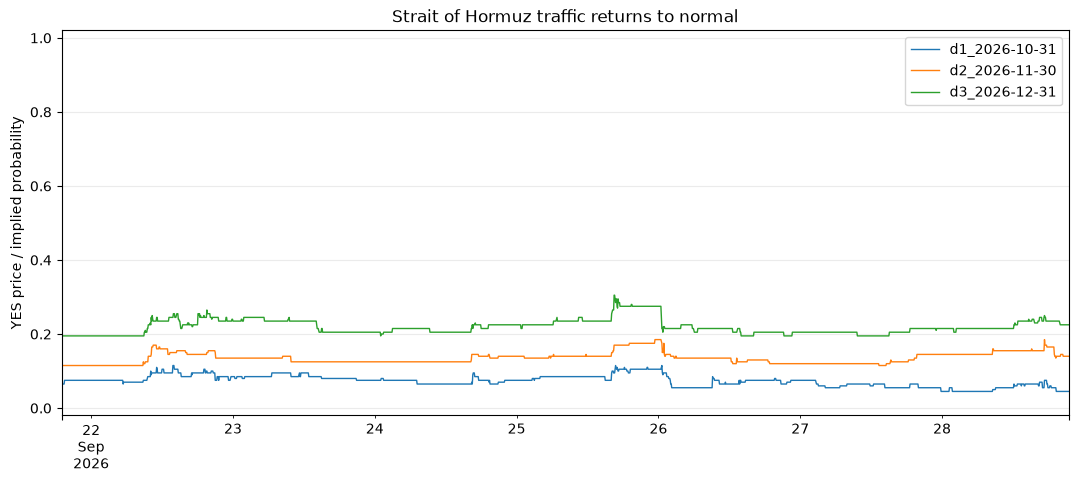

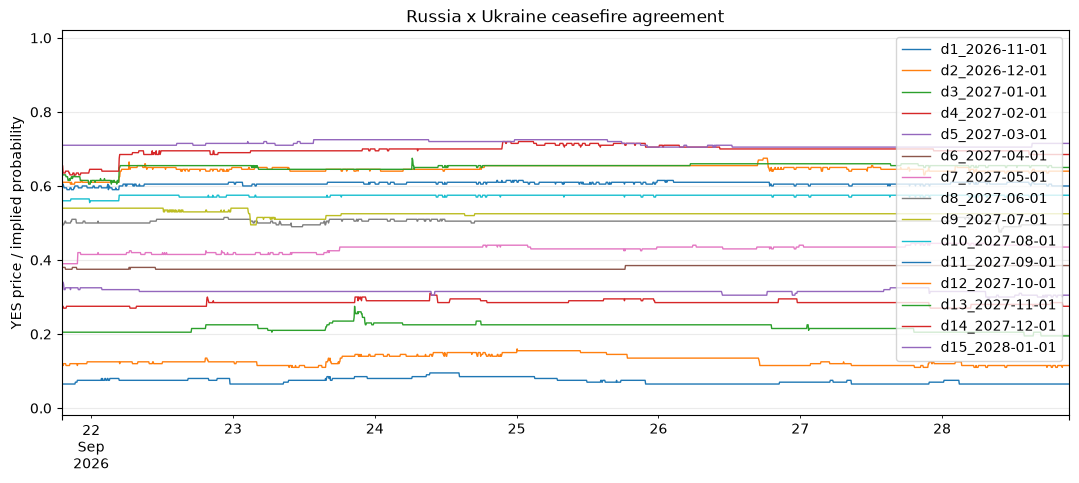

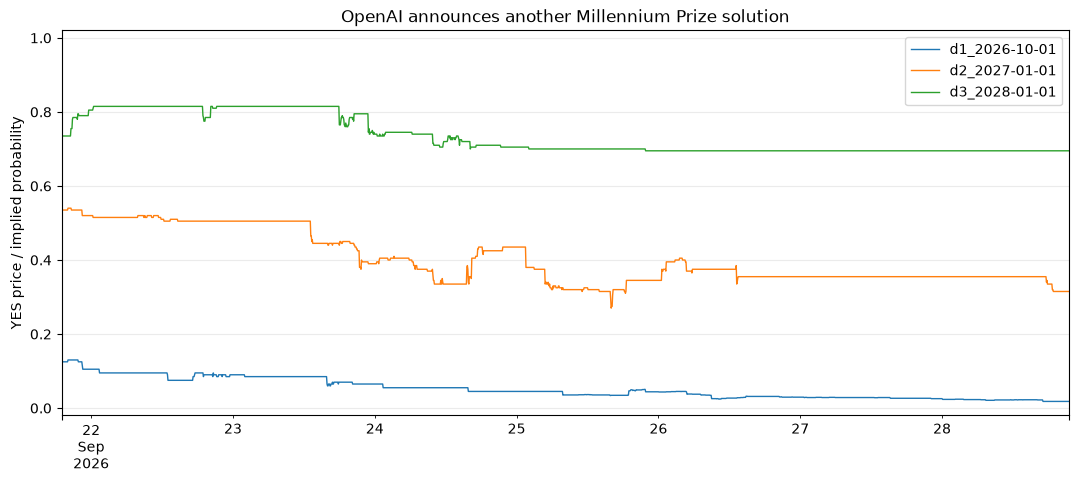

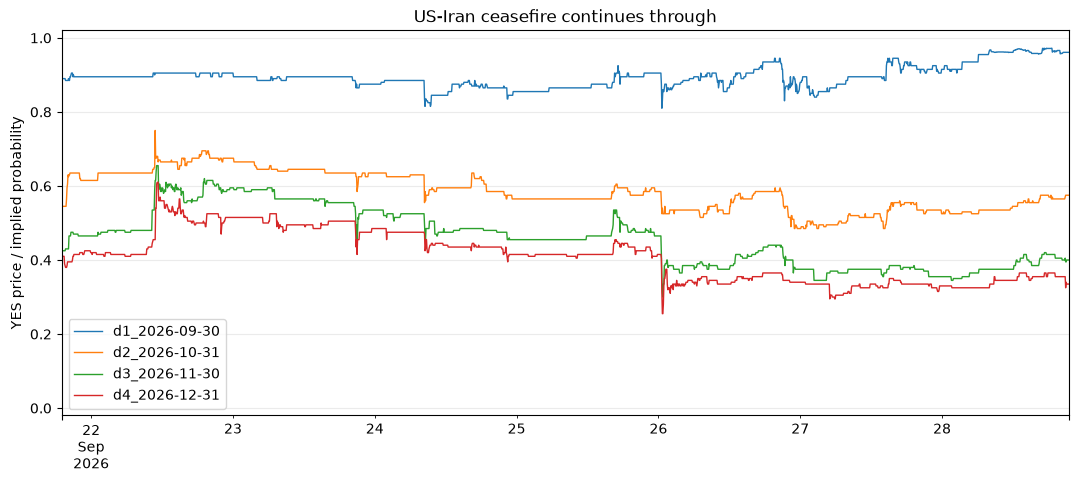

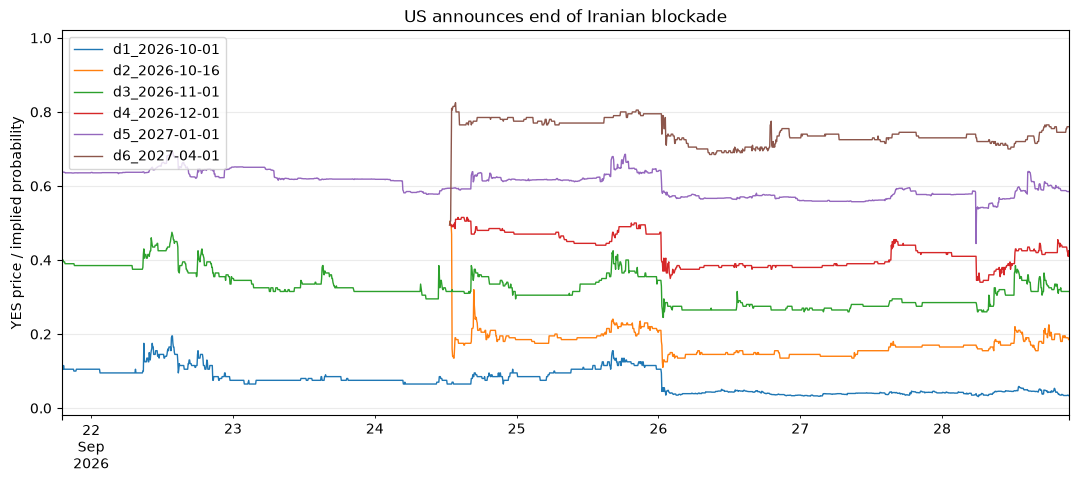

In [5]:
def plot_family_history(family_key: str, tail_rows: int | None = None):
    df = price_data[family_key]
    view = df.tail(tail_rows) if tail_rows else df

    ax = view.plot(figsize=(13, 5), linewidth=1)
    ax.set_title(EVENTS[family_key]["name"])
    ax.set_ylabel("YES price / implied probability")
    ax.set_xlabel("")
    ax.set_ylim(-0.02, 1.02)
    ax.grid(alpha=0.25)
    plt.show()


for family_key in price_data:
    plot_family_history(family_key)


## 5. Convert prices into interval masses and conditional hazards

### `by` curve

If the prices are \(F(t_1), F(t_2), ..., F(t_n)\), then:

- first bucket mass = \(F(t_1)\)
- later interval mass = \(F(t_i)-F(t_{i-1})\)
- tail = \(1-F(t_n)\)

The tail means **after the last deadline or never**. Those cannot be separated from these contracts alone.

The interval conditional hazard is:

\[
h_i=\frac{F(t_i)-F(t_{i-1})}{1-F(t_{i-1})}
\]

### `through` curve

If prices are survival probabilities \(S(t)\):

- failure before first deadline = \(1-S(t_1)\)
- later interval failure mass = \(S(t_{i-1})-S(t_i)\)
- terminal survival mass = \(S(t_n)\)

and the conditional failure hazard is:

\[
h_i=\frac{S(t_{i-1})-S(t_i)}{S(t_{i-1})}
\]


hormuz_normal | 2026-09-28 21:30:00+00:00
Latest curve:


,price_%
d1_2026-10-31,4.5
d2_2026-11-30,14.0
d3_2026-12-31,22.5


Implied interval masses:


,mass_%
by_d1_2026-10-31,4.5
d1_2026-10-31__to__d2_2026-11-30,9.5
d2_2026-11-30__to__d3_2026-12-31,8.5
after_last_or_never,77.5


Conditional hazards:


,conditional_%
h_d1_2026-10-31,4.50
h_d2_2026-11-30,9.95
h_d3_2026-12-31,9.88


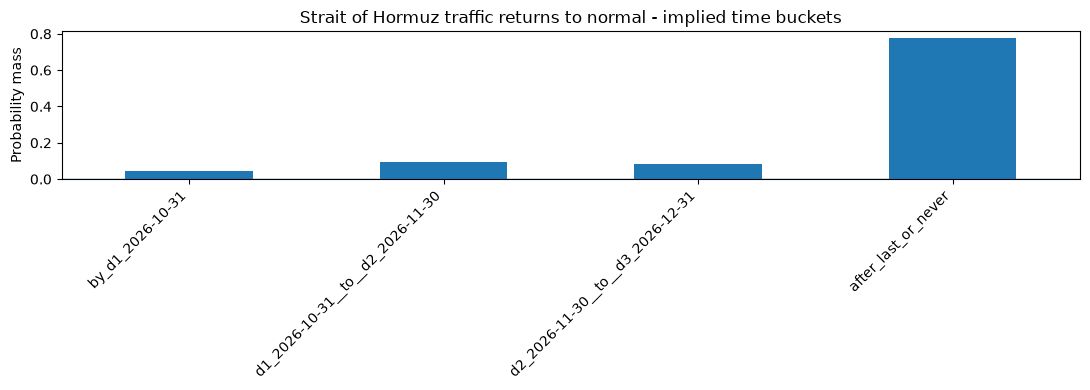


russia_ukraine_ceasefire | 2026-09-28 21:30:00+00:00
Latest curve:


,price_%
d1_2026-11-01,6.5
d2_2026-12-01,11.5
d3_2027-01-01,19.5
d4_2027-02-01,27.5
d5_2027-03-01,30.5
d6_2027-04-01,38.5
d7_2027-05-01,43.5
d8_2027-06-01,49.5
d9_2027-07-01,52.5
d10_2027-08-01,57.5


Implied interval masses:


,mass_%
by_d1_2026-11-01,6.5
d1_2026-11-01__to__d2_2026-12-01,5.0
d2_2026-12-01__to__d3_2027-01-01,8.0
d3_2027-01-01__to__d4_2027-02-01,8.0
d4_2027-02-01__to__d5_2027-03-01,3.0
d5_2027-03-01__to__d6_2027-04-01,8.0
d6_2027-04-01__to__d7_2027-05-01,5.0
d7_2027-05-01__to__d8_2027-06-01,6.0
d8_2027-06-01__to__d9_2027-07-01,3.0
d9_2027-07-01__to__d10_2027-08-01,5.0


Conditional hazards:


,conditional_%
h_d1_2026-11-01,6.50
h_d2_2026-12-01,5.35
h_d3_2027-01-01,9.04
h_d4_2027-02-01,9.94
h_d5_2027-03-01,4.14
h_d6_2027-04-01,11.51
h_d7_2027-05-01,8.13
h_d8_2027-06-01,10.62
h_d9_2027-07-01,5.94
h_d10_2027-08-01,10.53


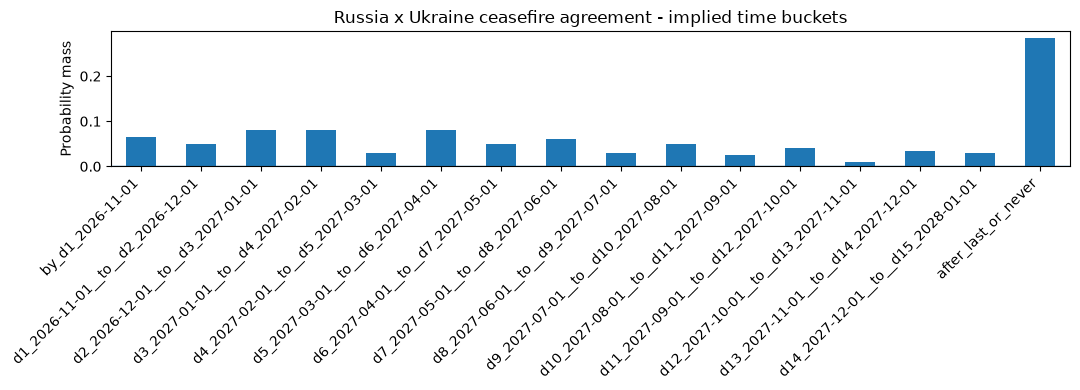


openai_millennium | 2026-09-28 21:30:00+00:00
Latest curve:


,price_%
d1_2026-10-01,1.8
d2_2027-01-01,31.5
d3_2028-01-01,69.5


Implied interval masses:


,mass_%
by_d1_2026-10-01,1.8
d1_2026-10-01__to__d2_2027-01-01,29.7
d2_2027-01-01__to__d3_2028-01-01,38.0
after_last_or_never,30.5


Conditional hazards:


,conditional_%
h_d1_2026-10-01,1.80
h_d2_2027-01-01,30.24
h_d3_2028-01-01,55.47


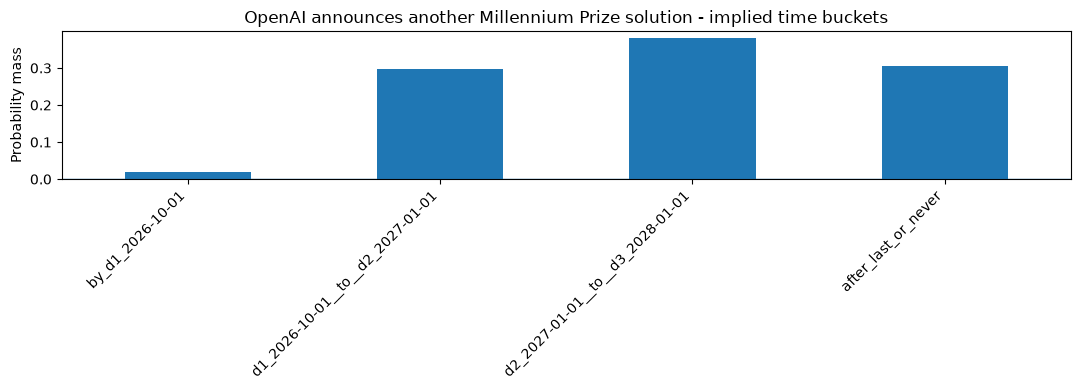


us_iran_ceasefire_survival | 2026-09-28 21:30:00+00:00
Latest curve:


,price_%
d1_2026-09-30,96.1
d2_2026-10-31,57.5
d3_2026-11-30,40.0
d4_2026-12-31,33.5


Implied interval masses:


,mass_%
fails_by_d1_2026-09-30,3.9
d1_2026-09-30__to__d2_2026-10-31,38.6
d2_2026-10-31__to__d3_2026-11-30,17.5
d3_2026-11-30__to__d4_2026-12-31,6.5
survives_through_last,33.5


Conditional hazards:


,conditional_%
h_d1_2026-09-30,3.90
h_d2_2026-10-31,40.17
h_d3_2026-11-30,30.43
h_d4_2026-12-31,16.25


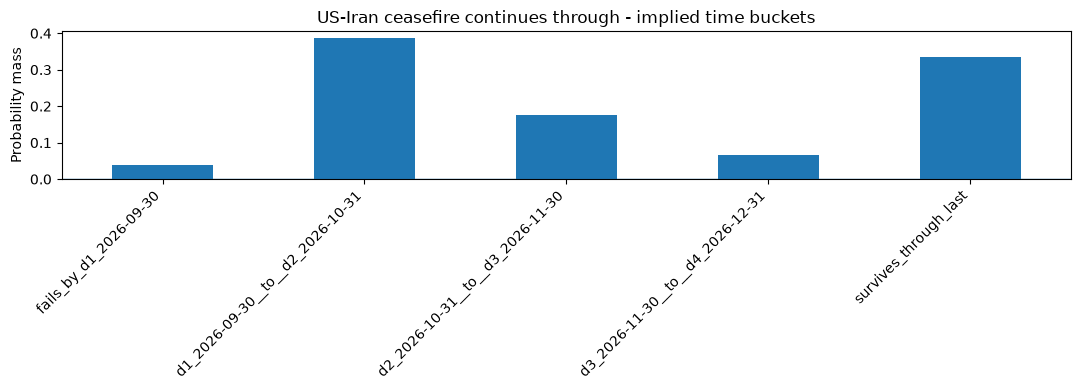


iran_blockade_end | 2026-09-28 21:30:00+00:00
Latest curve:


,price_%
d1_2026-10-01,3.35
d2_2026-10-16,18.50
d3_2026-11-01,31.50
d4_2026-12-01,41.00
d5_2027-01-01,58.45
d6_2027-04-01,76.00


Implied interval masses:


,mass_%
by_d1_2026-10-01,3.35
d1_2026-10-01__to__d2_2026-10-16,15.15
d2_2026-10-16__to__d3_2026-11-01,13.00
d3_2026-11-01__to__d4_2026-12-01,9.50
d4_2026-12-01__to__d5_2027-01-01,17.45
d5_2027-01-01__to__d6_2027-04-01,17.55
after_last_or_never,24.00


Conditional hazards:


,conditional_%
h_d1_2026-10-01,3.35
h_d2_2026-10-16,15.68
h_d3_2026-11-01,15.95
h_d4_2026-12-01,13.87
h_d5_2027-01-01,29.58
h_d6_2027-04-01,42.24


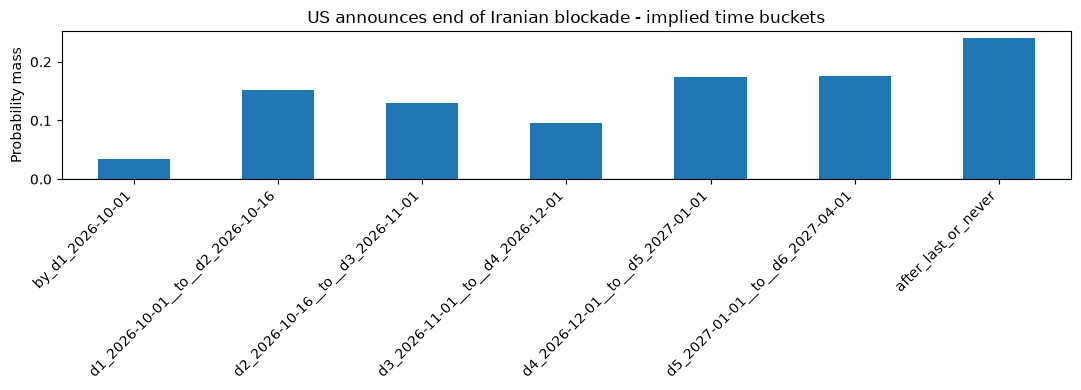

In [6]:
def probability_components(row: pd.Series, mode: str):
    p = row.dropna().astype(float)
    if p.empty:
        return pd.Series(dtype=float), pd.Series(dtype=float)

    masses = {}
    hazards = {}

    if mode == "by":
        masses[f"by_{p.index[0]}"] = p.iloc[0]
        hazards[f"h_{p.index[0]}"] = p.iloc[0]

        for i in range(1, len(p)):
            prev, cur = p.iloc[i-1], p.iloc[i]
            masses[f"{p.index[i-1]}__to__{p.index[i]}"] = cur - prev

            survival_before = 1 - prev
            hazards[f"h_{p.index[i]}"] = (
                (cur - prev) / survival_before
                if survival_before > 1e-12 else np.nan
            )

        masses["after_last_or_never"] = 1 - p.iloc[-1]

    elif mode == "through":
        masses[f"fails_by_{p.index[0]}"] = 1 - p.iloc[0]
        hazards[f"h_{p.index[0]}"] = 1 - p.iloc[0]

        for i in range(1, len(p)):
            prev, cur = p.iloc[i-1], p.iloc[i]
            masses[f"{p.index[i-1]}__to__{p.index[i]}"] = prev - cur
            hazards[f"h_{p.index[i]}"] = (
                (prev - cur) / prev if prev > 1e-12 else np.nan
            )

        masses["survives_through_last"] = p.iloc[-1]

    else:
        raise ValueError("mode must be 'by' or 'through'")

    return pd.Series(masses), pd.Series(hazards)


latest_components = {}

for family_key, df in price_data.items():
    complete = df.dropna()
    if complete.empty:
        continue

    latest = complete.iloc[-1]
    mode = EVENTS[family_key]["mode"]
    masses, hazards = probability_components(latest, mode)
    latest_components[family_key] = (masses, hazards)

    print("\n", "=" * 80)
    print(family_key, "|", complete.index[-1])
    print("Latest curve:")
    display((latest * 100).round(2).to_frame("price_%"))

    print("Implied interval masses:")
    display((masses * 100).round(2).to_frame("mass_%"))

    print("Conditional hazards:")
    display((hazards * 100).round(2).to_frame("conditional_%"))

    ax = masses.plot(kind="bar", figsize=(11, 4))
    ax.set_title(f"{EVENTS[family_key]['name']} - implied time buckets")
    ax.set_ylabel("Probability mass")
    ax.axhline(0, linewidth=1)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


## 6. Monotonicity violations

This catches the hard-arbitrage extreme:

- `by`: an earlier deadline trading above a later deadline;
- `through`: an earlier survival deadline trading below a later survival deadline.

It is still only a **price-history diagnostic**. A real arbitrage claim needs simultaneous executable bid/ask prices and sufficient size.

In [7]:
def monotonicity_report(family_key: str, tolerance: float = 1e-12):
    df = price_data[family_key].dropna()
    mode = EVENTS[family_key]["mode"]

    if mode == "by":
        pair_violations = df.diff(axis=1).iloc[:, 1:] < -tolerance
    else:
        pair_violations = df.diff(axis=1).iloc[:, 1:] > tolerance

    any_violation = pair_violations.any(axis=1)

    summary = pd.DataFrame({
        "rows": [len(df)],
        "rows_with_violation": [int(any_violation.sum())],
        "share_with_violation": [float(any_violation.mean()) if len(df) else np.nan],
    })

    return summary, df.loc[any_violation], pair_violations


for family_key in price_data:
    summary, violations, _ = monotonicity_report(family_key)
    print("\n", family_key)
    display(summary.style.format({"share_with_violation": "{:.3%}"}))

    if not violations.empty:
        display(violations.tail(20).style.format("{:.2%}"))



 hormuz_normal


,rows,rows_with_violation,share_with_violation
0,2047,0,0.000%



 russia_ukraine_ceasefire


,rows,rows_with_violation,share_with_violation
0,2046,142,6.940%


,d1_2026-11-01,d2_2026-12-01,d3_2027-01-01,d4_2027-02-01,d5_2027-03-01,d6_2027-04-01,d7_2027-05-01,d8_2027-06-01,d9_2027-07-01,d10_2027-08-01,d11_2027-09-01,d12_2027-10-01,d13_2027-11-01,d14_2027-12-01,d15_2028-01-01
timestamp,,,,,,,,,,,,,,,
2026-09-26 16:55:00+00:00,6.50%,13.50%,22.50%,28.50%,30.50%,38.50%,43.50%,50.50%,52.50%,57.50%,61.00%,67.00%,66.00%,70.00%,70.50%
2026-09-26 17:00:00+00:00,6.50%,13.00%,22.50%,28.50%,30.50%,38.50%,43.50%,50.50%,52.50%,57.50%,61.00%,67.00%,66.00%,70.00%,70.50%
2026-09-26 17:05:00+00:00,6.50%,12.50%,22.50%,28.50%,30.50%,38.50%,43.50%,50.50%,52.50%,57.50%,61.00%,67.00%,66.00%,70.00%,70.50%
2026-09-26 17:10:00+00:00,6.50%,11.50%,22.50%,28.50%,30.50%,38.50%,43.50%,50.50%,52.50%,57.50%,61.00%,67.00%,66.00%,70.00%,70.50%
2026-09-26 17:15:00+00:00,6.50%,11.50%,22.50%,28.50%,30.50%,38.50%,43.50%,50.50%,52.50%,57.50%,61.00%,67.00%,66.00%,70.00%,70.50%
2026-09-26 17:20:00+00:00,6.50%,11.50%,22.50%,28.50%,30.50%,38.50%,43.50%,50.50%,52.50%,57.50%,61.00%,67.00%,66.00%,70.00%,70.50%
2026-09-26 17:25:00+00:00,6.50%,11.50%,22.50%,28.50%,30.50%,38.50%,43.50%,50.50%,52.50%,57.50%,61.00%,67.00%,66.00%,70.00%,70.50%
2026-09-26 17:30:00+00:00,6.50%,11.50%,22.50%,28.50%,30.50%,38.50%,43.50%,50.50%,52.50%,57.50%,61.00%,67.00%,66.00%,70.00%,70.50%
2026-09-26 17:35:00+00:00,6.50%,11.50%,22.50%,28.50%,30.50%,38.50%,43.50%,50.50%,52.50%,57.50%,61.00%,67.00%,66.00%,70.00%,70.50%


...


 us_iran_ceasefire_survival


,rows,rows_with_violation,share_with_violation
0,2047,0,0.000%



 iran_blockade_end


,rows,rows_with_violation,share_with_violation
0,1259,5,0.397%


,d1_2026-10-01,d2_2026-10-16,d3_2026-11-01,d4_2026-12-01,d5_2027-01-01,d6_2027-04-01
timestamp,,,,,,
2026-09-24 12:40:00+00:00,6.50%,49.50%,31.50%,49.50%,59.40%,49.50%
2026-09-24 12:45:00+00:00,6.50%,50.50%,31.50%,50.00%,59.35%,50.50%
2026-09-24 12:50:00+00:00,6.50%,49.50%,31.50%,49.50%,59.40%,50.50%
2026-09-24 12:55:00+00:00,6.50%,49.50%,31.50%,49.50%,59.35%,66.00%
2026-09-24 13:00:00+00:00,6.50%,47.00%,31.50%,49.00%,59.40%,81.00%


## 7. Correlation of **changes**, not just levels

Raw deadline prices will often be highly correlated because they refer to the same underlying event. The more useful object is the correlation of bucket-to-bucket **price changes**.

This does not establish causality. It is simply a first check for contracts that typically move together.

hormuz_normal change correlation


,d1_2026-10-31,d2_2026-11-30,d3_2026-12-31
d1_2026-10-31,1.000,0.180,0.017
d2_2026-11-30,0.180,1.000,0.128
d3_2026-12-31,0.017,0.128,1.000


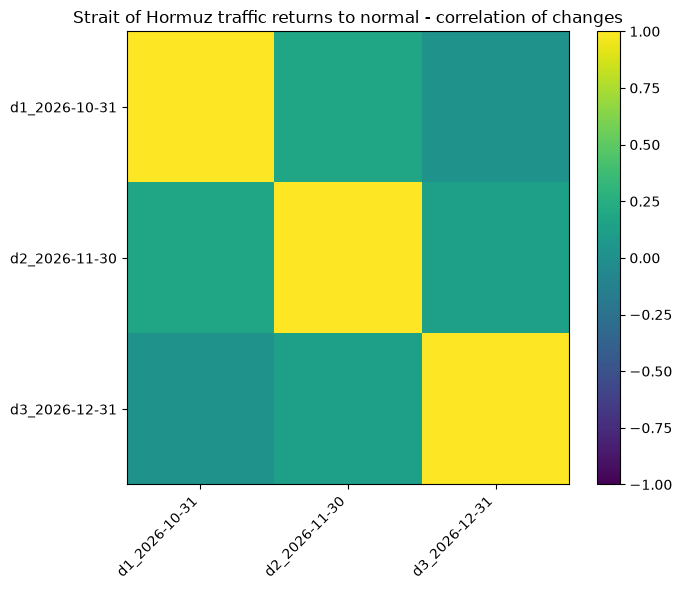

russia_ukraine_ceasefire change correlation


,d1_2026-11-01,d2_2026-12-01,d3_2027-01-01,d4_2027-02-01,d5_2027-03-01,d6_2027-04-01,d7_2027-05-01,d8_2027-06-01,d9_2027-07-01,d10_2027-08-01,d11_2027-09-01,d12_2027-10-01,d13_2027-11-01,d14_2027-12-01,d15_2028-01-01
d1_2026-11-01,1.000,0.052,0.070,0.033,-0.026,0.000,-0.000,-0.023,-0.024,-0.038,0.000,-0.052,-0.032,-0.008,0.000
d2_2026-12-01,0.052,1.000,-0.013,0.021,0.042,0.000,0.090,0.022,0.031,0.105,0.078,0.081,0.046,-0.027,0.000
d3_2027-01-01,0.070,-0.013,1.000,-0.024,-0.000,0.000,0.052,-0.000,0.054,-0.019,0.032,0.028,0.012,-0.013,0.029
d4_2027-02-01,0.033,0.021,-0.024,1.000,0.042,0.028,-0.000,-0.027,-0.039,0.071,0.035,0.048,0.019,0.007,0.000
d5_2027-03-01,-0.026,0.042,-0.000,0.042,1.000,-0.033,0.039,-0.022,-0.000,0.072,0.074,0.078,0.015,0.016,0.000
d6_2027-04-01,0.000,0.000,0.000,0.028,-0.033,1.000,0.052,0.000,0.000,-0.000,0.000,0.116,-0.021,-0.022,-0.000
d7_2027-05-01,-0.000,0.090,0.052,-0.000,0.039,0.052,1.000,0.092,-0.018,0.168,0.122,0.066,0.047,0.012,0.044
d8_2027-06-01,-0.023,0.022,-0.000,-0.027,-0.022,0.000,0.092,1.000,0.071,0.063,0.072,0.062,0.047,-0.028,0.000
d9_2027-07-01,-0.024,0.031,0.054,-0.039,-0.000,0.000,-0.018,0.071,1.000,0.000,0.031,0.013,-0.014,-0.023,0.089
d10_2027-08-01,-0.038,0.105,-0.019,0.071,0.072,-0.000,0.168,0.063,0.000,1.000,0.355,0.222,0.276,0.134,-0.000


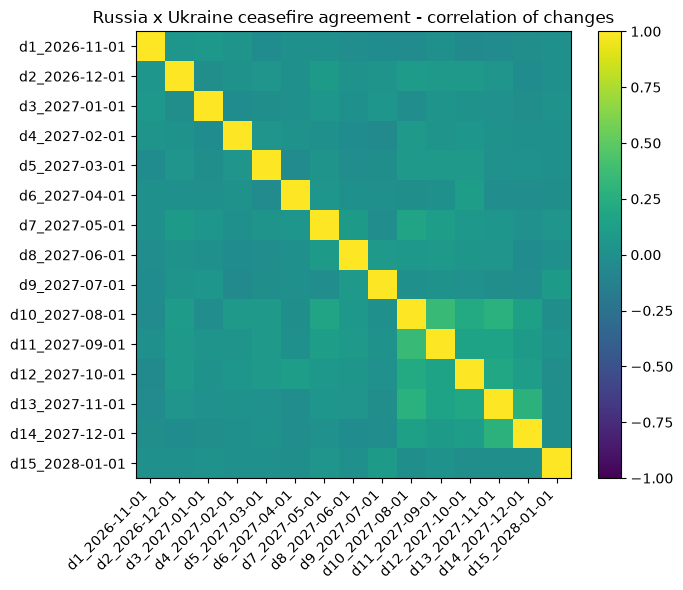

openai_millennium change correlation


,d1_2026-10-01,d2_2027-01-01,d3_2028-01-01
d1_2026-10-01,1.000,0.058,0.018
d2_2027-01-01,0.058,1.000,0.034
d3_2028-01-01,0.018,0.034,1.000


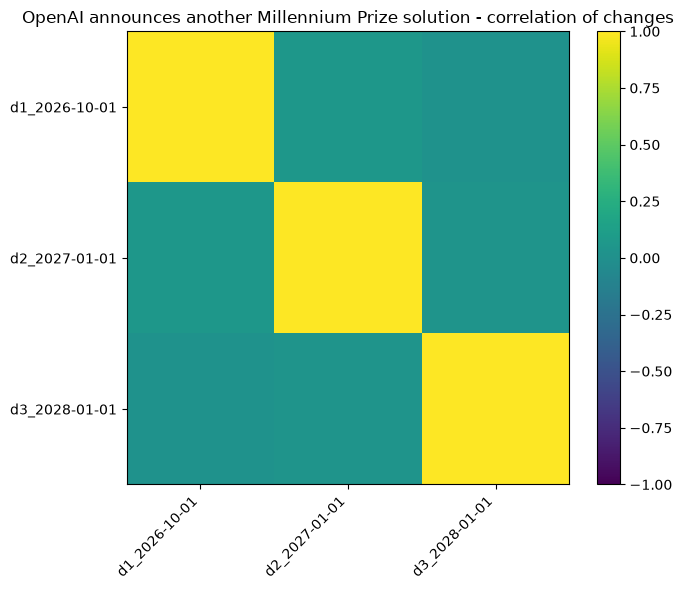

us_iran_ceasefire_survival change correlation


,d1_2026-09-30,d2_2026-10-31,d3_2026-11-30,d4_2026-12-31
d1_2026-09-30,1.000,0.196,0.212,0.169
d2_2026-10-31,0.196,1.000,0.230,-0.014
d3_2026-11-30,0.212,0.230,1.000,0.445
d4_2026-12-31,0.169,-0.014,0.445,1.000


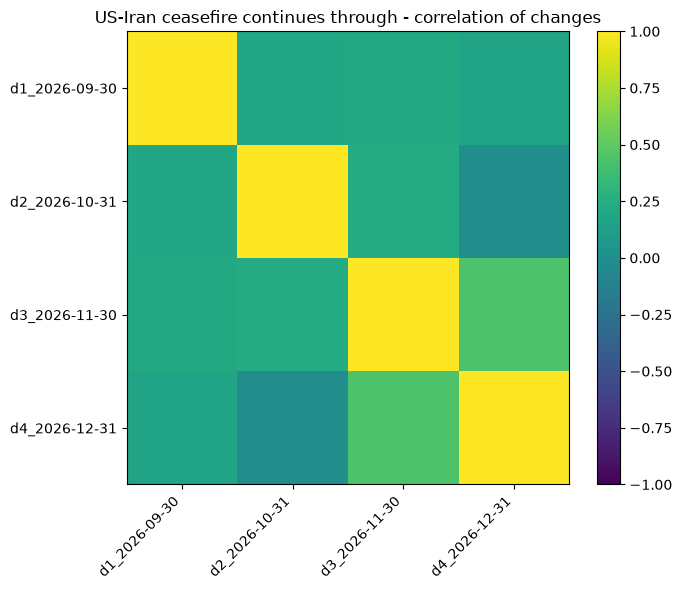

iran_blockade_end change correlation


,d1_2026-10-01,d2_2026-10-16,d3_2026-11-01,d4_2026-12-01,d5_2027-01-01,d6_2027-04-01
d1_2026-10-01,1.000,0.018,0.334,0.068,0.149,0.105
d2_2026-10-16,0.018,1.000,0.099,0.056,0.029,-0.024
d3_2026-11-01,0.334,0.099,1.000,0.118,0.213,0.032
d4_2026-12-01,0.068,0.056,0.118,1.000,-0.081,-0.000
d5_2027-01-01,0.149,0.029,0.213,-0.081,1.000,0.067
d6_2027-04-01,0.105,-0.024,0.032,-0.000,0.067,1.000


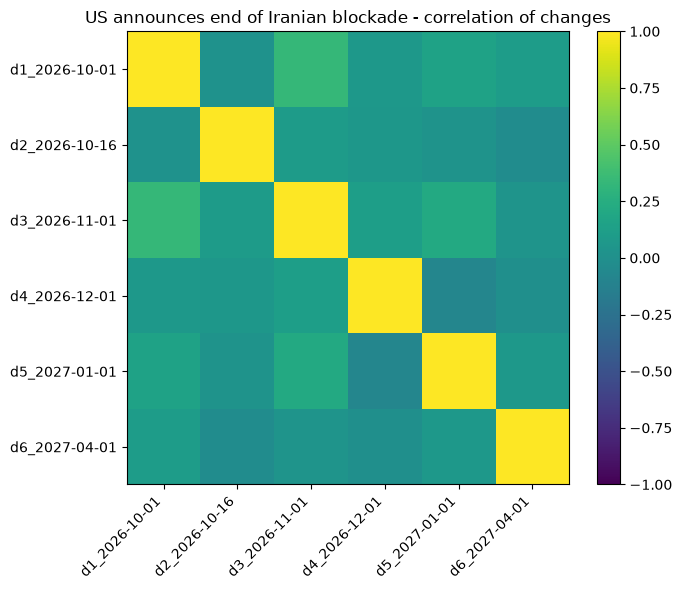

In [8]:
def plot_change_correlation(family_key: str):
    df = price_data[family_key].dropna()
    changes = df.diff().dropna()
    corr = changes.corr()

    print(family_key, "change correlation")
    display(corr.round(3))

    fig, ax = plt.subplots(figsize=(7, 6))
    image = ax.imshow(corr.values, vmin=-1, vmax=1, aspect="auto")
    ax.set_xticks(range(len(corr.columns)))
    ax.set_xticklabels(corr.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(corr.index)))
    ax.set_yticklabels(corr.index)
    ax.set_title(f"{EVENTS[family_key]['name']} - correlation of changes")
    fig.colorbar(image, ax=ax)
    plt.tight_layout()
    plt.show()

    return changes, corr


change_data = {}
for family_key in price_data:
    changes, corr = plot_change_correlation(family_key)
    change_data[family_key] = changes


## 8. Lead/lag scan inside each event family

For each ordered pair \(X, Y\), this calculates:

\[
corr(\Delta X_t,\Delta Y_{t+k})
\]

A **positive lag** means `X` moves first and `Y` is measured later.

This is exactly the pattern we care about if, for example, December tends to react first and November catches up one or two buckets later.

In [9]:
def lagged_corr(x: pd.Series, y: pd.Series, lag: int, min_obs: int = 50):
    # positive lag: x_t compared with y_(t+lag), so x "leads" y
    joined = pd.concat([x, y.shift(-lag)], axis=1).dropna()
    if len(joined) < min_obs:
        return np.nan, len(joined)
    return joined.iloc[:, 0].corr(joined.iloc[:, 1]), len(joined)


def lead_lag_scan(changes: pd.DataFrame, max_lag: int = 6, min_obs: int = 50):
    records = []

    for x in changes.columns:
        for y in changes.columns:
            if x == y:
                continue

            for lag in range(1, max_lag + 1):
                corr, n = lagged_corr(changes[x], changes[y], lag, min_obs=min_obs)
                records.append({
                    "leader": x,
                    "follower": y,
                    "lag_buckets": lag,
                    "lag_minutes": lag * ANALYSIS_BUCKET_SECONDS / 60,
                    "correlation": corr,
                    "observations": n,
                })

    result = pd.DataFrame(records).dropna(subset=["correlation"])
    if result.empty:
        return result

    # Show strongest absolute relationships first.
    return result.assign(abs_corr=result["correlation"].abs()).sort_values(
        "abs_corr", ascending=False
    ).drop(columns="abs_corr")


lead_lag_results = {}

for family_key, changes in change_data.items():
    result = lead_lag_scan(changes, max_lag=6)
    lead_lag_results[family_key] = result

    print("\n", family_key, "- strongest lead/lag relationships")
    display(result.head(15).style.format({"correlation": "{:.3f}"}))



 hormuz_normal - strongest lead/lag relationships


,leader,follower,lag_buckets,lag_minutes,correlation,observations
30,d3_2026-12-31,d2_2026-11-30,1,5.000000,0.180,2045
25,d3_2026-12-31,d1_2026-10-31,2,10.000000,0.117,2044
35,d3_2026-12-31,d2_2026-11-30,6,30.000000,0.112,2040
10,d1_2026-10-31,d3_2026-12-31,5,25.000000,0.100,2041
6,d1_2026-10-31,d3_2026-12-31,1,5.000000,0.084,2045
4,d1_2026-10-31,d2_2026-11-30,5,25.000000,0.082,2041
24,d3_2026-12-31,d1_2026-10-31,1,5.000000,0.077,2045
13,d2_2026-11-30,d1_2026-10-31,2,10.000000,0.077,2044
18,d2_2026-11-30,d3_2026-12-31,1,5.000000,0.074,2045
32,d3_2026-12-31,d2_2026-11-30,3,15.000000,0.058,2043



 russia_ukraine_ceasefire - strongest lead/lag relationships


,leader,follower,lag_buckets,lag_minutes,correlation,observations
451,d6_2027-04-01,d7_2027-05-01,2,10.000000,-0.182,2043
181,d3_2027-01-01,d4_2027-02-01,2,10.000000,0.154,2043
362,d5_2027-03-01,d6_2027-04-01,3,15.000000,0.134,2042
955,d12_2027-10-01,d6_2027-04-01,2,10.000000,-0.116,2043
429,d6_2027-04-01,d2_2026-12-01,4,20.000000,-0.113,2041
765,d10_2027-08-01,d2_2026-12-01,4,20.000000,-0.106,2041
639,d8_2027-06-01,d10_2027-08-01,4,20.000000,-0.105,2041
180,d3_2027-01-01,d4_2027-02-01,1,5.000000,0.105,2044
897,d11_2027-09-01,d10_2027-08-01,4,20.000000,-0.105,2041
1083,d13_2027-11-01,d14_2027-12-01,4,20.000000,0.094,2041



 openai_millennium - strongest lead/lag relationships


,leader,follower,lag_buckets,lag_minutes,correlation,observations
14,d2_2027-01-01,d1_2026-10-01,3,15.000000,-0.055,2043
7,d1_2026-10-01,d3_2028-01-01,2,10.000000,0.052,2044
28,d3_2028-01-01,d1_2026-10-01,5,25.000000,0.052,2041
16,d2_2027-01-01,d1_2026-10-01,5,25.000000,0.042,2041
12,d2_2027-01-01,d1_2026-10-01,1,5.000000,0.033,2045
6,d1_2026-10-01,d3_2028-01-01,1,5.000000,-0.027,2045
9,d1_2026-10-01,d3_2028-01-01,4,20.000000,0.026,2042
32,d3_2028-01-01,d2_2027-01-01,3,15.000000,-0.026,2043
21,d2_2027-01-01,d3_2028-01-01,4,20.000000,0.025,2042
29,d3_2028-01-01,d1_2026-10-01,6,30.000000,-0.022,2040



 us_iran_ceasefire_survival - strongest lead/lag relationships


,leader,follower,lag_buckets,lag_minutes,correlation,observations
30,d2_2026-10-31,d4_2026-12-31,1,5.000000,0.243,2045
12,d1_2026-09-30,d4_2026-12-31,1,5.000000,0.203,2045
6,d1_2026-09-30,d3_2026-11-30,1,5.000000,0.174,2045
48,d3_2026-11-30,d4_2026-12-31,1,5.000000,0.172,2045
66,d4_2026-12-31,d3_2026-11-30,1,5.000000,0.171,2045
69,d4_2026-12-31,d3_2026-11-30,4,20.000000,-0.144,2042
49,d3_2026-11-30,d4_2026-12-31,2,10.000000,0.129,2044
42,d3_2026-11-30,d2_2026-10-31,1,5.000000,0.117,2045
25,d2_2026-10-31,d3_2026-11-30,2,10.000000,0.112,2044
47,d3_2026-11-30,d2_2026-10-31,6,30.000000,0.100,2040



 iran_blockade_end - strongest lead/lag relationships


,leader,follower,lag_buckets,lag_minutes,correlation,observations
157,d6_2027-04-01,d2_2026-10-16,2,10.000000,-0.472,1256
156,d6_2027-04-01,d2_2026-10-16,1,5.000000,-0.471,1257
138,d5_2027-01-01,d4_2026-12-01,1,5.000000,0.281,1257
90,d4_2026-12-01,d1_2026-10-01,1,5.000000,0.210,1257
70,d3_2026-11-01,d2_2026-10-16,5,25.000000,0.187,1253
15,d1_2026-10-01,d4_2026-12-01,4,20.000000,-0.162,1254
9,d1_2026-10-01,d3_2026-11-01,4,20.000000,-0.149,1254
106,d4_2026-12-01,d3_2026-11-01,5,25.000000,-0.143,1253
120,d5_2027-01-01,d1_2026-10-01,1,5.000000,0.134,1257
14,d1_2026-10-01,d4_2026-12-01,3,15.000000,0.114,1255


## 9. Adjacent interval-spread mean reversion

For a `by` family, the adjacent interval price is:

\[
F(t_{i+1})-F(t_i)
\]

For a `through` family, the equivalent failure interval price is:

\[
S(t_i)-S(t_{i+1})
\]

We standardise each interval spread with a rolling z-score and ask whether unusually wide/narrow intervals subsequently move back toward their rolling mean.

This is closer to the "shape of the curve is temporarily wrong" thesis than raw price correlation.

In [10]:
ROLLING_WINDOW = 12 * 12   # 12 hours at 5-minute buckets
MIN_ROLLING_OBS = ROLLING_WINDOW // 2
Z_THRESHOLD = 2.0
HORIZONS = [1, 3, 6, 12]  # 5m, 15m, 30m, 60m at current bucket size


def adjacent_interval_spreads(family_key: str):
    df = price_data[family_key].dropna()
    mode = EVENTS[family_key]["mode"]

    spreads = {}
    for i in range(len(df.columns) - 1):
        a, b = df.columns[i], df.columns[i + 1]
        if mode == "by":
            spreads[f"{a} -> {b}"] = df[b] - df[a]
        else:
            spreads[f"{a} -> {b}"] = df[a] - df[b]

    return pd.DataFrame(spreads, index=df.index)


def rolling_z(series: pd.Series, window=ROLLING_WINDOW, min_periods=MIN_ROLLING_OBS):
    mean = series.rolling(window, min_periods=min_periods).mean()
    std = series.rolling(window, min_periods=min_periods).std(ddof=1)
    return (series - mean) / std.replace(0, np.nan)


def spread_reversion_event_study(spread: pd.Series, z: pd.Series,
                                 threshold=Z_THRESHOLD, horizons=HORIZONS,
                                 cooldown=None):
    cooldown = cooldown or max(horizons)
    candidates = np.flatnonzero((z.abs() >= threshold).fillna(False).values)

    # Keep signals separated so one long episode is not counted every 5 minutes.
    chosen = []
    last = -10**9
    for i in candidates:
        if i - last >= cooldown:
            chosen.append(i)
            last = i

    rows = []
    for h in horizons:
        observations = []
        for i in chosen:
            j = i + h
            if j >= len(spread):
                continue
            if pd.isna(spread.iloc[i]) or pd.isna(spread.iloc[j]) or pd.isna(z.iloc[i]):
                continue

            # If z>0 we expect spread to fall; if z<0 we expect spread to rise.
            direction = -np.sign(z.iloc[i])
            move = spread.iloc[j] - spread.iloc[i]
            signed_move = direction * move

            observations.append({
                "signed_move": signed_move,
                "abs_error_reduction": abs(spread.iloc[i]) - abs(spread.iloc[j]),
            })

        obs = pd.DataFrame(observations)
        rows.append({
            "horizon_buckets": h,
            "horizon_minutes": h * ANALYSIS_BUCKET_SECONDS / 60,
            "signals": len(obs),
            "directional_hit_rate": (
                (obs["signed_move"] > 0).mean() if not obs.empty else np.nan
            ),
            "avg_signed_move_pp": (
                obs["signed_move"].mean() * 100 if not obs.empty else np.nan
            ),
        })

    return pd.DataFrame(rows), chosen


spread_results = {}

for family_key in price_data:
    spreads = adjacent_interval_spreads(family_key)
    family_output = {}

    print("\n", "=" * 80)
    print(family_key)

    for col in spreads.columns:
        z = rolling_z(spreads[col])
        study, chosen = spread_reversion_event_study(spreads[col], z)
        family_output[col] = {"spread": spreads[col], "z": z, "study": study}

        print("\nInterval:", col)
        display(study.style.format({
            "directional_hit_rate": "{:.1%}",
            "avg_signed_move_pp": "{:.3f}",
        }))

    spread_results[family_key] = family_output



hormuz_normal

Interval: d1_2026-10-31 -> d2_2026-11-30


,horizon_buckets,horizon_minutes,signals,directional_hit_rate,avg_signed_move_pp
0,1,5.000000,42,16.7%,0.060
1,3,15.000000,42,31.0%,0.298
2,6,30.000000,42,35.7%,0.190
3,12,60.000000,42,42.9%,0.262



Interval: d2_2026-11-30 -> d3_2026-12-31


,horizon_buckets,horizon_minutes,signals,directional_hit_rate,avg_signed_move_pp
0,1,5.000000,38,13.2%,0.000
1,3,15.000000,38,26.3%,0.145
2,6,30.000000,38,42.1%,0.263
3,12,60.000000,38,55.3%,0.526



russia_ukraine_ceasefire

Interval: d1_2026-11-01 -> d2_2026-12-01


...

,horizon_buckets,horizon_minutes,signals,directional_hit_rate,avg_signed_move_pp
0,1,5.000000,20,40.0%,0.375
1,3,15.000000,20,60.0%,0.675
2,6,30.000000,20,75.0%,0.925
3,12,60.000000,20,55.0%,0.650



Interval: d4_2026-12-01 -> d5_2027-01-01


,horizon_buckets,horizon_minutes,signals,directional_hit_rate,avg_signed_move_pp
0,1,5.000000,19,42.1%,0.389
1,3,15.000000,19,68.4%,0.439
2,6,30.000000,19,63.2%,0.447
3,12,60.000000,19,68.4%,0.566



Interval: d5_2027-01-01 -> d6_2027-04-01


,horizon_buckets,horizon_minutes,signals,directional_hit_rate,avg_signed_move_pp
0,1,5.000000,14,42.9%,0.939
1,3,15.000000,14,42.9%,0.979
2,6,30.000000,14,64.3%,1.518
3,12,60.000000,14,85.7%,1.761


## 10. Out-of-sample neighbour model for the curve

For every **interior** deadline, fit:

\[
p_{\text{middle}} = a + b\,p_{\text{left}} + c\,p_{\text{right}} + \epsilon
\]

using only the first 70% of the history. We then freeze the coefficients and inspect residuals in the final 30%.

A positive residual means the middle contract is **rich relative to its neighbours** under this simple historical relationship. A negative residual means it is **cheap**.

This is intentionally simple. The goal is to see whether a stable relative-value relationship exists before trying more complex ML.


hormuz_normal

d2_2026-11-30 from d1_2026-10-31 + d3_2026-12-31
beta: [0.0029 0.1175 0.5513]


,horizon_buckets,horizon_minutes,signals,residual_reversion_rate,target_direction_hit_rate,avg_target_move_pp,avg_residual_reduction_pp
0,1,5.000000,23,21.7%,4.3%,0.022,0.091
1,3,15.000000,23,21.7%,4.3%,-0.043,-0.005
2,6,30.000000,23,30.4%,4.3%,-0.043,0.020
3,12,60.000000,23,30.4%,8.7%,0.043,0.089


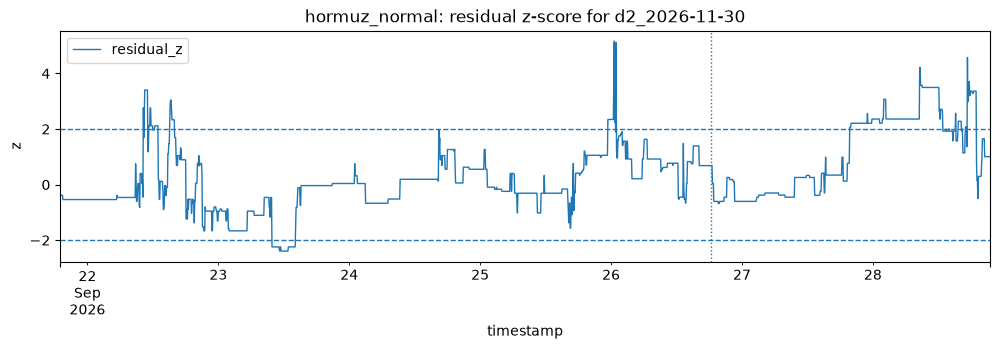


russia_ukraine_ceasefire

d2_2026-12-01 from d1_2026-11-01 + d3_2027-01-01
beta: [-0.0622  0.528   0.7095]


,horizon_buckets,horizon_minutes,signals,residual_reversion_rate,target_direction_hit_rate,avg_target_move_pp,avg_residual_reduction_pp
0,1,5.000000,1,0.0%,0.0%,0.000,0.000
1,3,15.000000,1,100.0%,0.0%,0.000,1.064
2,6,30.000000,1,100.0%,0.0%,0.000,0.709
3,12,60.000000,1,100.0%,100.0%,0.500,1.209


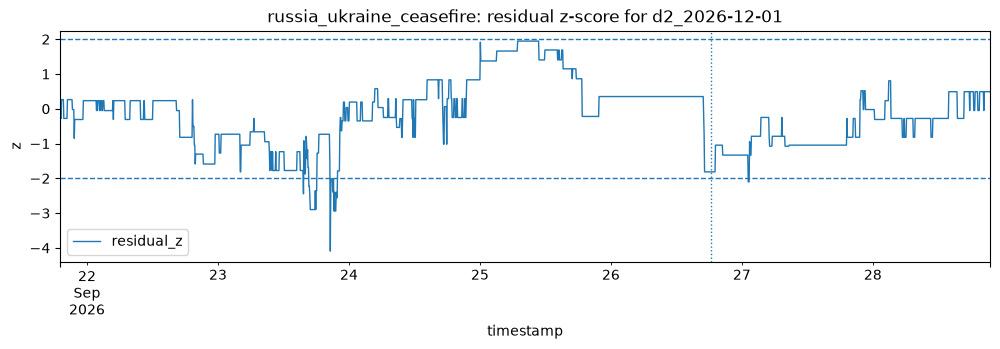


d3_2027-01-01 from d2_2026-12-01 + d4_2027-02-01
beta: [-0.0467  0.2412  0.8244]


,horizon_buckets,horizon_minutes,signals,residual_reversion_rate,target_direction_hit_rate,avg_target_move_pp,avg_residual_reduction_pp
0,1,5.000000,7,0.0%,0.0%,0.000,-0.017
1,3,15.000000,7,0.0%,0.0%,0.000,-0.017
2,6,30.000000,7,28.6%,0.0%,0.000,0.059
3,12,60.000000,6,50.0%,16.7%,0.167,0.235


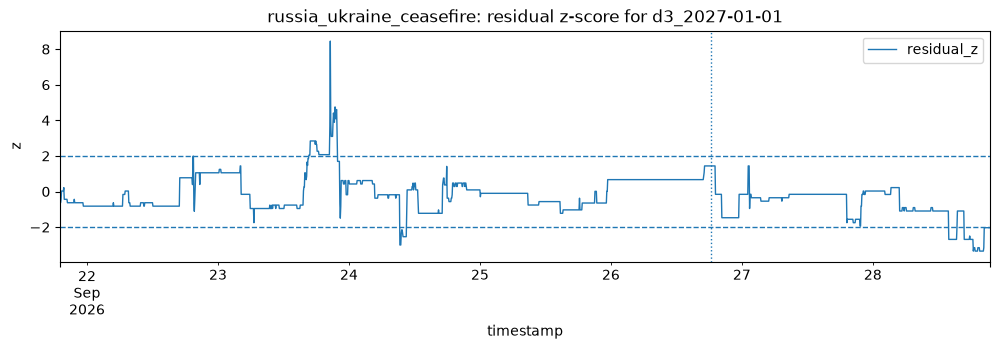


d4_2027-02-01 from d3_2027-01-01 + d5_2027-03-01
beta: [ 0.2302  0.4686 -0.1537]


,horizon_buckets,horizon_minutes,signals,residual_reversion_rate,target_direction_hit_rate,avg_target_move_pp,avg_residual_reduction_pp
0,1,5.000000,6,16.7%,0.0%,0.000,0.013
1,3,15.000000,6,33.3%,16.7%,0.167,0.154
2,6,30.000000,6,33.3%,16.7%,0.167,0.167
3,12,60.000000,6,66.7%,33.3%,0.333,0.333


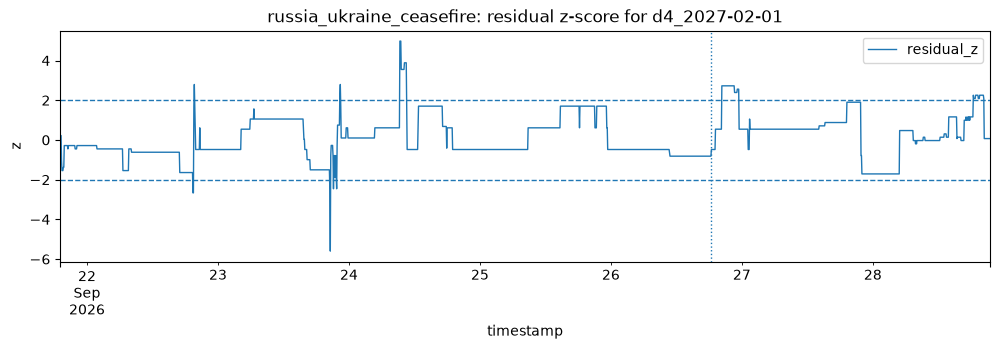


d5_2027-03-01 from d4_2027-02-01 + d6_2027-04-01
beta: [ 0.5041 -0.2124 -0.3402]


,horizon_buckets,horizon_minutes,signals,residual_reversion_rate,target_direction_hit_rate,avg_target_move_pp,avg_residual_reduction_pp
0,1,5.000000,22,4.5%,4.5%,-0.023,-0.023
1,3,15.000000,22,4.5%,4.5%,-0.045,-0.045
2,6,30.000000,22,9.1%,9.1%,0.000,0.000
3,12,60.000000,22,27.3%,27.3%,0.068,0.071


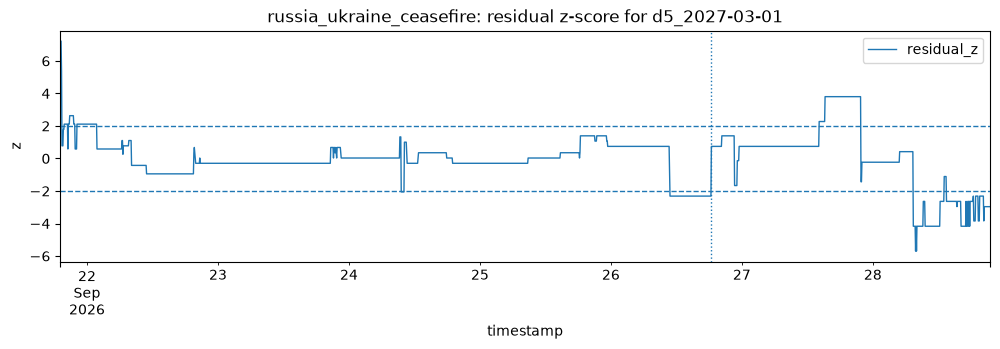


d6_2027-04-01 from d5_2027-03-01 + d7_2027-05-01
beta: [ 0.4798 -0.3571  0.0234]


,horizon_buckets,horizon_minutes,signals,residual_reversion_rate,target_direction_hit_rate,avg_target_move_pp,avg_residual_reduction_pp
0,1,5.000000,28,7.1%,0.0%,0.000,0.001
1,3,15.000000,28,17.9%,0.0%,0.000,0.033
2,6,30.000000,28,21.4%,0.0%,0.000,0.027
3,12,60.000000,28,21.4%,0.0%,0.000,0.008


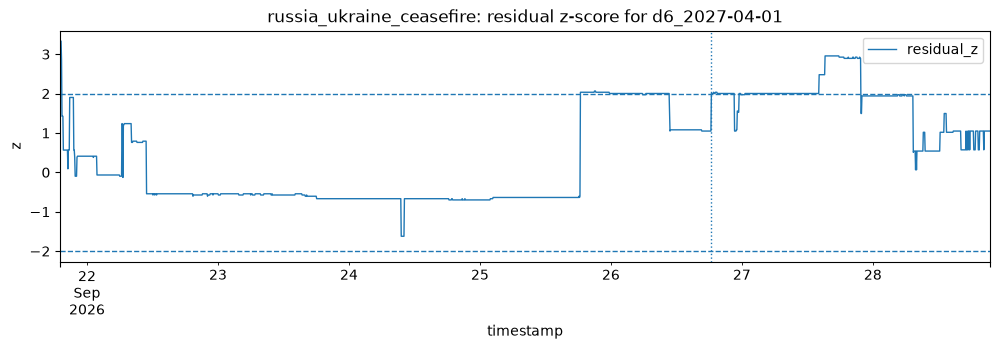


d7_2027-05-01 from d6_2027-04-01 + d8_2027-06-01
beta: [-0.0802  0.574   0.5749]


,horizon_buckets,horizon_minutes,signals,residual_reversion_rate,target_direction_hit_rate,avg_target_move_pp,avg_residual_reduction_pp
0,1,5.000000,1,0.0%,0.0%,0.000,-0.575
1,3,15.000000,1,0.0%,0.0%,0.000,-0.287
2,6,30.000000,1,0.0%,0.0%,0.000,-0.287
3,12,60.000000,1,100.0%,0.0%,0.000,0.287


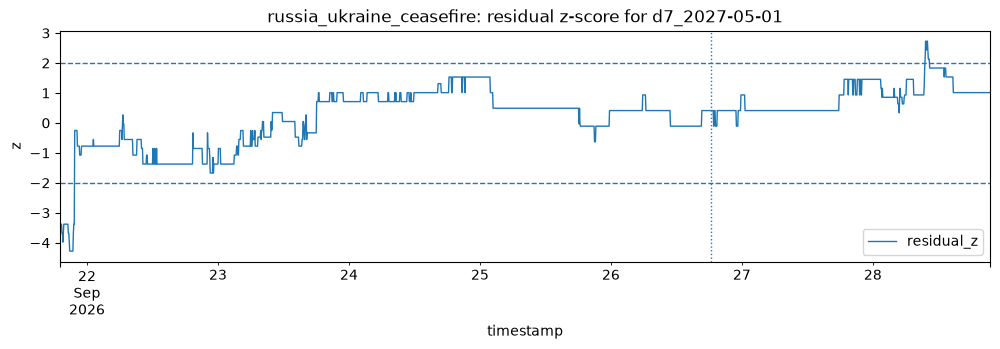


d8_2027-06-01 from d7_2027-05-01 + d9_2027-07-01
beta: [0.3312 0.1549 0.2044]


,horizon_buckets,horizon_minutes,signals,residual_reversion_rate,target_direction_hit_rate,avg_target_move_pp,avg_residual_reduction_pp
0,1,5.000000,13,7.7%,0.0%,-0.038,-0.033
1,3,15.000000,13,15.4%,0.0%,-0.077,-0.065
2,6,30.000000,13,15.4%,0.0%,-0.115,-0.103
3,12,60.000000,13,23.1%,15.4%,0.115,0.096


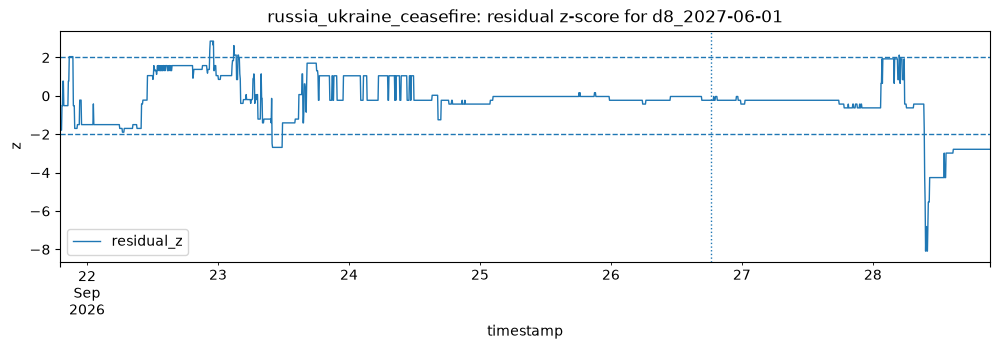


d9_2027-07-01 from d8_2027-06-01 + d10_2027-08-01
beta: [ 0.5832  0.8055 -0.8091]


,horizon_buckets,horizon_minutes,signals,residual_reversion_rate,target_direction_hit_rate,avg_target_move_pp,avg_residual_reduction_pp
0,1,5.000000,1,0.0%,0.0%,0.000,-0.805
1,3,15.000000,1,0.0%,0.0%,0.000,-0.403
2,6,30.000000,1,0.0%,0.0%,0.000,-0.403
3,12,60.000000,1,100.0%,0.0%,0.000,0.403


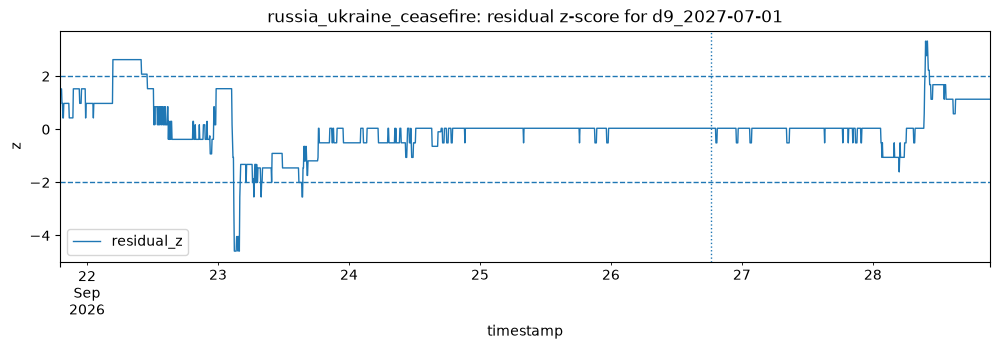


d10_2027-08-01 from d9_2027-07-01 + d11_2027-09-01
beta: [0.1371 0.0443 0.6797]


,horizon_buckets,horizon_minutes,signals,residual_reversion_rate,target_direction_hit_rate,avg_target_move_pp,avg_residual_reduction_pp
0,1,5.000000,8,50.0%,12.5%,0.063,0.190
1,3,15.000000,8,50.0%,12.5%,0.063,0.190
2,6,30.000000,8,62.5%,12.5%,0.063,0.232
3,12,60.000000,7,57.1%,0.0%,0.000,0.194


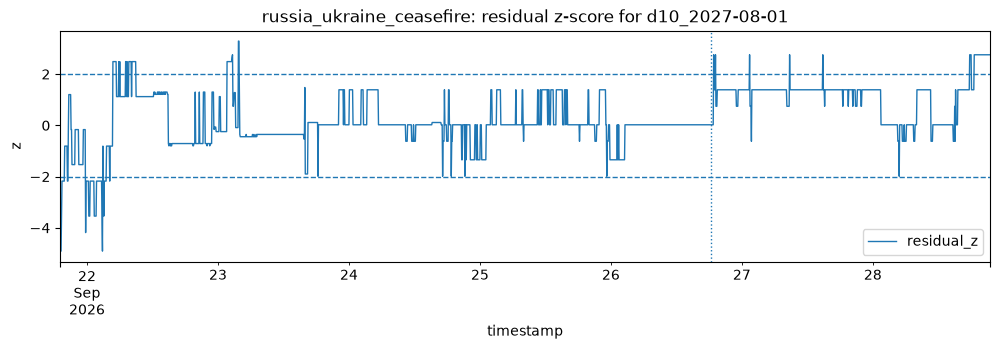


d11_2027-09-01 from d10_2027-08-01 + d12_2027-10-01
beta: [0.1938 0.5725 0.1317]


,horizon_buckets,horizon_minutes,signals,residual_reversion_rate,target_direction_hit_rate,avg_target_move_pp,avg_residual_reduction_pp
0,1,5.000000,8,50.0%,37.5%,0.188,0.223
1,3,15.000000,8,50.0%,37.5%,0.188,0.215
2,6,30.000000,8,62.5%,50.0%,0.250,0.278
3,12,60.000000,7,57.1%,57.1%,0.286,0.267


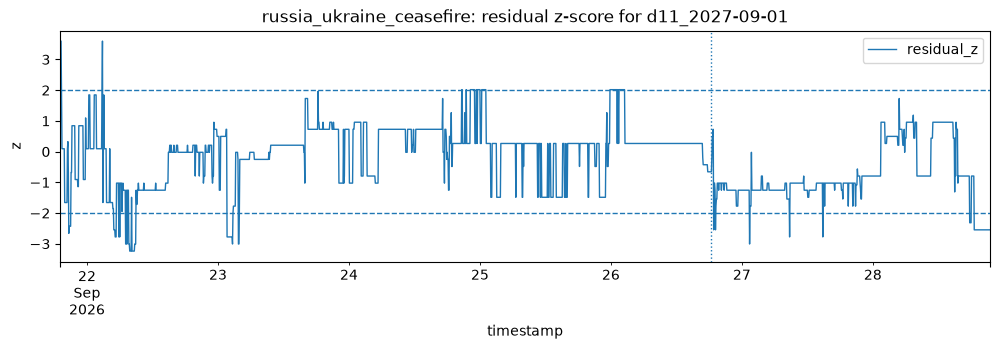


d12_2027-10-01 from d11_2027-09-01 + d13_2027-11-01
beta: [-0.2498  0.5609  0.855 ]


,horizon_buckets,horizon_minutes,signals,residual_reversion_rate,target_direction_hit_rate,avg_target_move_pp,avg_residual_reduction_pp
0,1,5.000000,17,52.9%,29.4%,0.206,0.265
1,3,15.000000,17,64.7%,41.2%,0.382,0.363
2,6,30.000000,17,64.7%,64.7%,0.559,0.289
3,12,60.000000,17,76.5%,76.5%,0.647,0.445


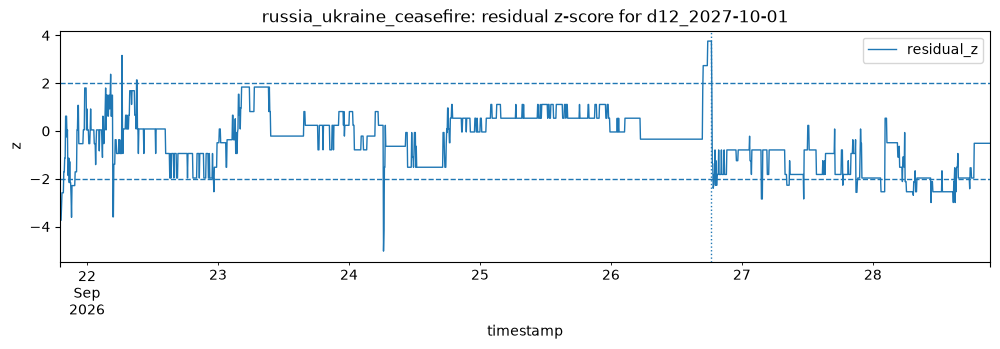


d13_2027-11-01 from d12_2027-10-01 + d14_2027-12-01
beta: [0.1447 0.7043 0.0719]


,horizon_buckets,horizon_minutes,signals,residual_reversion_rate,target_direction_hit_rate,avg_target_move_pp,avg_residual_reduction_pp
0,1,5.000000,35,5.7%,0.0%,0.000,0.030
1,3,15.000000,35,22.9%,2.9%,0.014,0.098
2,6,30.000000,35,31.4%,8.6%,0.029,0.113
3,12,60.000000,35,34.3%,8.6%,0.043,0.150


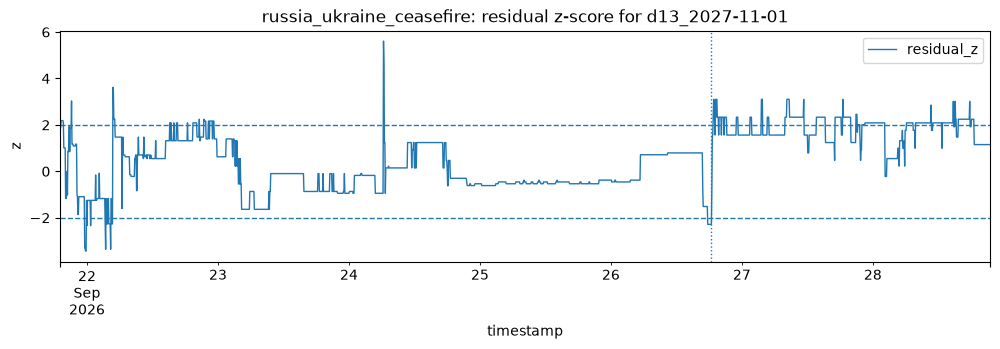


d14_2027-12-01 from d13_2027-11-01 + d15_2028-01-01
beta: [-0.8304  1.4451  0.8197]


,horizon_buckets,horizon_minutes,signals,residual_reversion_rate,target_direction_hit_rate,avg_target_move_pp,avg_residual_reduction_pp
0,1,5.000000,4,0.0%,0.0%,0.000,0.000
1,3,15.000000,4,0.0%,0.0%,0.000,0.000
2,6,30.000000,4,25.0%,0.0%,0.000,0.181
3,12,60.000000,4,25.0%,0.0%,0.000,0.181


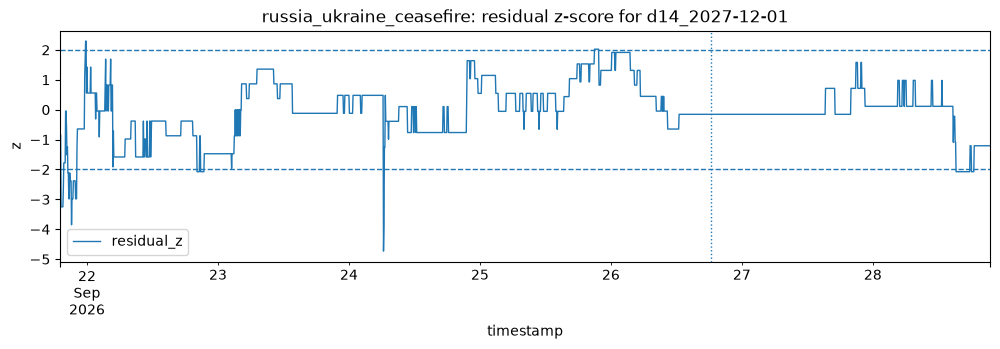


openai_millennium

d2_2027-01-01 from d1_2026-10-01 + d3_2028-01-01
beta: [-0.0811  1.6066  0.5371]


,horizon_buckets,horizon_minutes,signals,residual_reversion_rate,target_direction_hit_rate,avg_target_move_pp,avg_residual_reduction_pp
0,1,5.000000,0,nan%,nan%,nan,nan
1,3,15.000000,0,nan%,nan%,nan,nan
2,6,30.000000,0,nan%,nan%,nan,nan
3,12,60.000000,0,nan%,nan%,nan,nan


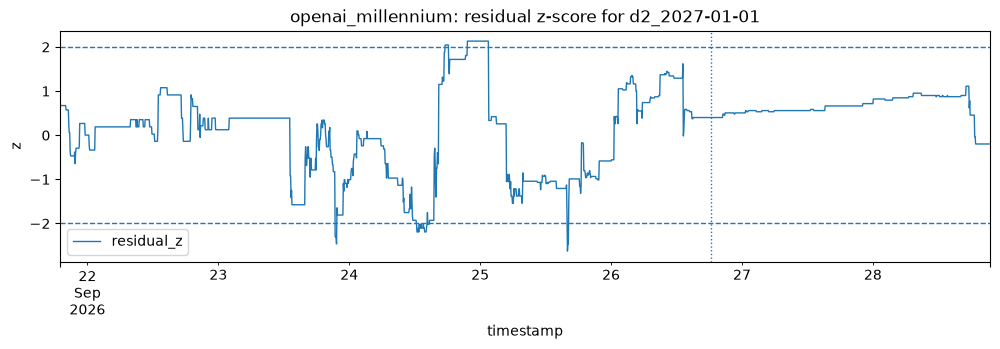


us_iran_ceasefire_survival

d2_2026-10-31 from d1_2026-09-30 + d3_2026-11-30
beta: [-0.0858  0.4735  0.5541]


,horizon_buckets,horizon_minutes,signals,residual_reversion_rate,target_direction_hit_rate,avg_target_move_pp,avg_residual_reduction_pp
0,1,5.000000,21,33.3%,23.8%,0.167,0.250
1,3,15.000000,21,38.1%,28.6%,0.238,0.221
2,6,30.000000,21,57.1%,38.1%,0.500,0.451
3,12,60.000000,21,52.4%,47.6%,0.524,0.301


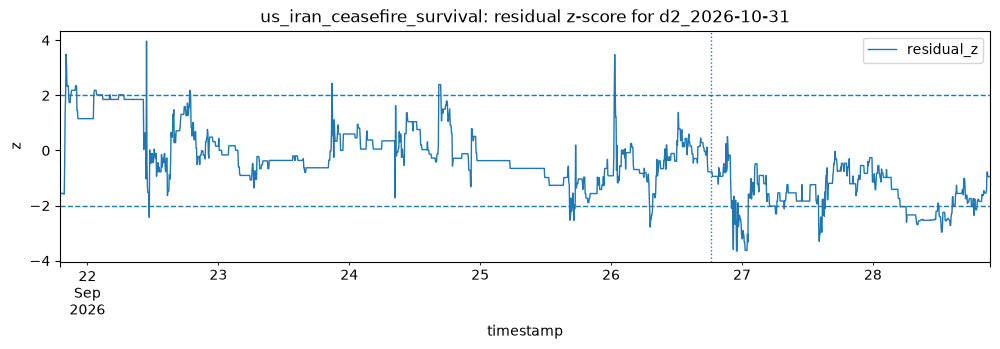


d3_2026-11-30 from d2_2026-10-31 + d4_2026-12-31
beta: [-0.1149  0.3831  0.856 ]


,horizon_buckets,horizon_minutes,signals,residual_reversion_rate,target_direction_hit_rate,avg_target_move_pp,avg_residual_reduction_pp
0,1,5.000000,6,33.3%,0.0%,-0.083,0.131
1,3,15.000000,6,66.7%,0.0%,-0.083,0.448
2,6,30.000000,6,66.7%,33.3%,0.083,0.583
3,12,60.000000,6,100.0%,50.0%,0.500,1.007


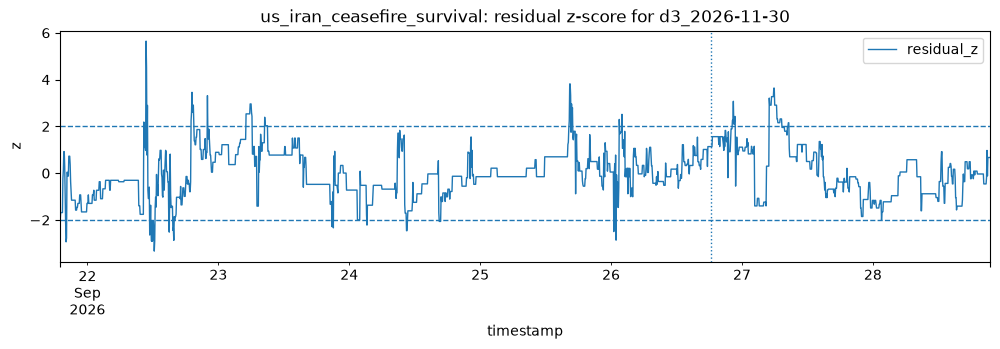


iran_blockade_end

d2_2026-10-16 from d1_2026-10-01 + d3_2026-11-01
beta: [-0.0165  0.2354  0.5723]


,horizon_buckets,horizon_minutes,signals,residual_reversion_rate,target_direction_hit_rate,avg_target_move_pp,avg_residual_reduction_pp
0,1,5.000000,0,nan%,nan%,nan,nan
1,3,15.000000,0,nan%,nan%,nan,nan
2,6,30.000000,0,nan%,nan%,nan,nan
3,12,60.000000,0,nan%,nan%,nan,nan


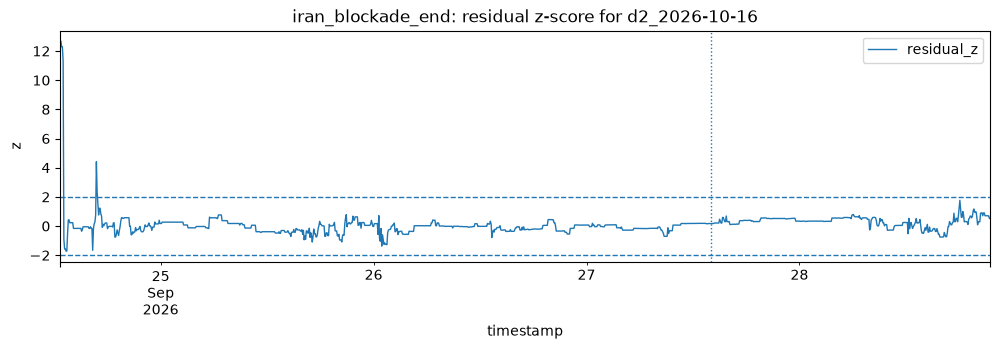


d3_2026-11-01 from d2_2026-10-16 + d4_2026-12-01
beta: [0.0385 0.2922 0.4991]


,horizon_buckets,horizon_minutes,signals,residual_reversion_rate,target_direction_hit_rate,avg_target_move_pp,avg_residual_reduction_pp
0,1,5.000000,7,85.7%,14.3%,-0.071,0.523
1,3,15.000000,7,85.7%,57.1%,0.500,1.175
2,6,30.000000,7,100.0%,71.4%,1.286,1.600
3,12,60.000000,7,71.4%,85.7%,0.786,1.247


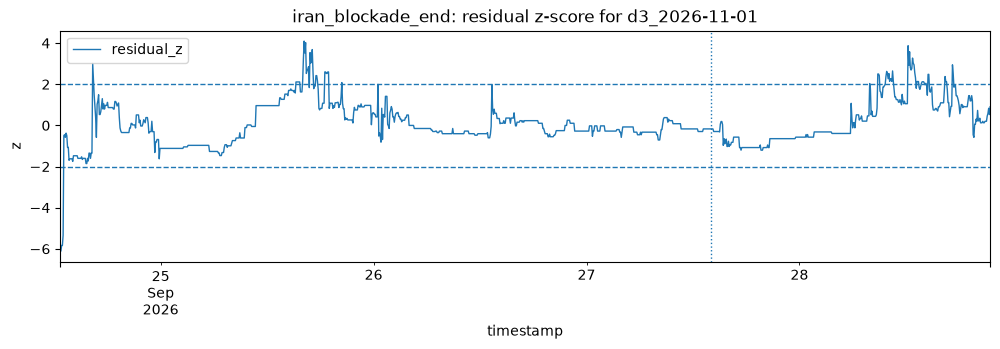


d4_2026-12-01 from d3_2026-11-01 + d5_2027-01-01
beta: [-0.1962  0.3575  0.8673]


,horizon_buckets,horizon_minutes,signals,residual_reversion_rate,target_direction_hit_rate,avg_target_move_pp,avg_residual_reduction_pp
0,1,5.000000,3,66.7%,66.7%,2.500,3.286
1,3,15.000000,3,100.0%,66.7%,2.167,4.039
2,6,30.000000,3,100.0%,66.7%,1.833,4.912
3,12,60.000000,3,100.0%,66.7%,2.833,4.991


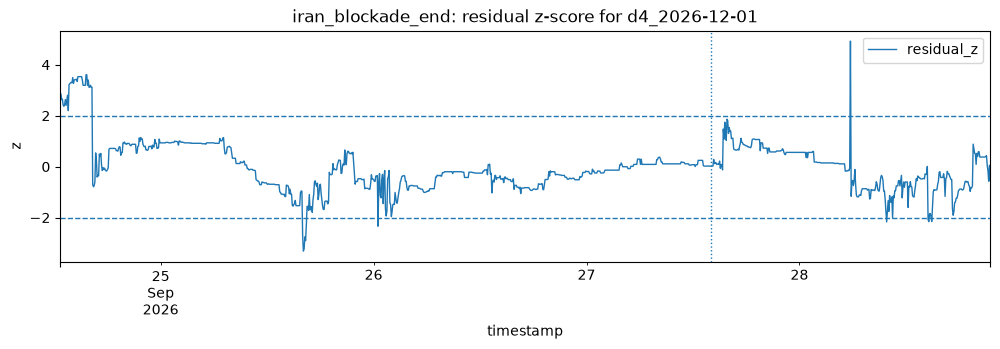


d5_2027-01-01 from d4_2026-12-01 + d6_2027-04-01
beta: [0.2364 0.4284 0.2335]


,horizon_buckets,horizon_minutes,signals,residual_reversion_rate,target_direction_hit_rate,avg_target_move_pp,avg_residual_reduction_pp
0,1,5.000000,2,50.0%,50.0%,4.700,6.092
1,3,15.000000,2,50.0%,50.0%,4.850,6.145
2,6,30.000000,2,100.0%,100.0%,5.300,6.166
3,12,60.000000,2,100.0%,100.0%,6.150,7.552


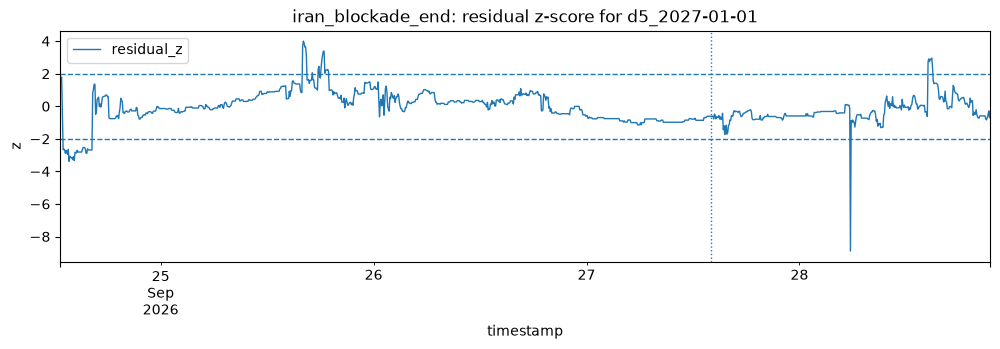

In [11]:
TRAIN_FRACTION = 0.70
RESIDUAL_Z_THRESHOLD = 2.0


def fit_neighbor_model(df: pd.DataFrame, target_index: int, train_fraction=TRAIN_FRACTION):
    if target_index <= 0 or target_index >= len(df.columns) - 1:
        raise ValueError("target_index must be an interior curve point")

    work = df.dropna().copy()
    left = work.columns[target_index - 1]
    target = work.columns[target_index]
    right = work.columns[target_index + 1]

    split = max(10, int(len(work) * train_fraction))
    train = work.iloc[:split]

    X_train = np.column_stack([
        np.ones(len(train)),
        train[left].values,
        train[right].values,
    ])
    y_train = train[target].values

    beta, *_ = np.linalg.lstsq(X_train, y_train, rcond=None)

    X_all = np.column_stack([
        np.ones(len(work)),
        work[left].values,
        work[right].values,
    ])
    predicted = pd.Series(X_all @ beta, index=work.index, name="predicted")
    residual = (work[target] - predicted).rename("residual")

    train_resid = residual.iloc[:split]
    mu = train_resid.mean()
    sigma = train_resid.std(ddof=1)

    z = ((residual - mu) / sigma).rename("residual_z") if sigma > 0 else residual * np.nan

    out = pd.DataFrame({
        "actual": work[target],
        "predicted": predicted,
        "residual": residual,
        "residual_z": z,
        "is_test": np.arange(len(work)) >= split,
    })

    return {
        "left": left,
        "target": target,
        "right": right,
        "beta": beta,
        "split_index": split,
        "data": out,
    }


def residual_event_study(model, threshold=RESIDUAL_Z_THRESHOLD,
                         horizons=HORIZONS, cooldown=None):
    data = model["data"]
    test = data[data["is_test"]].copy()
    cooldown = cooldown or max(horizons)

    candidate_positions = np.flatnonzero(
        (test["residual_z"].abs() >= threshold).fillna(False).values
    )

    chosen = []
    last = -10**9
    for pos in candidate_positions:
        if pos - last >= cooldown:
            chosen.append(pos)
            last = pos

    rows = []
    for h in horizons:
        records = []
        for pos in chosen:
            future = pos + h
            if future >= len(test):
                continue

            r0 = test["residual"].iloc[pos]
            r1 = test["residual"].iloc[future]
            p0 = test["actual"].iloc[pos]
            p1 = test["actual"].iloc[future]

            # Rich residual => expect target price down. Cheap => expect price up.
            direction = -np.sign(r0)

            records.append({
                "residual_reduction": abs(r0) - abs(r1),
                "signed_target_move": direction * (p1 - p0),
            })

        obs = pd.DataFrame(records)
        rows.append({
            "horizon_buckets": h,
            "horizon_minutes": h * ANALYSIS_BUCKET_SECONDS / 60,
            "signals": len(obs),
            "residual_reversion_rate": (
                (obs["residual_reduction"] > 0).mean() if not obs.empty else np.nan
            ),
            "target_direction_hit_rate": (
                (obs["signed_target_move"] > 0).mean() if not obs.empty else np.nan
            ),
            "avg_target_move_pp": (
                obs["signed_target_move"].mean() * 100 if not obs.empty else np.nan
            ),
            "avg_residual_reduction_pp": (
                obs["residual_reduction"].mean() * 100 if not obs.empty else np.nan
            ),
        })

    return pd.DataFrame(rows)


neighbor_models = {}

for family_key, df in price_data.items():
    complete = df.dropna()
    if len(complete.columns) < 3 or len(complete) < 100:
        continue

    print("\n", "=" * 80)
    print(family_key)

    family_models = []
    for target_index in range(1, len(complete.columns) - 1):
        model = fit_neighbor_model(complete, target_index)
        family_models.append(model)

        print(
            f"\n{model['target']} from "
            f"{model['left']} + {model['right']}"
        )
        print("beta:", np.round(model["beta"], 4))

        study = residual_event_study(model)
        display(study.style.format({
            "residual_reversion_rate": "{:.1%}",
            "target_direction_hit_rate": "{:.1%}",
            "avg_target_move_pp": "{:.3f}",
            "avg_residual_reduction_pp": "{:.3f}",
        }))

        data = model["data"]
        ax = data[["residual_z"]].plot(figsize=(12, 3), linewidth=1)
        ax.axhline(RESIDUAL_Z_THRESHOLD, linestyle="--", linewidth=1)
        ax.axhline(-RESIDUAL_Z_THRESHOLD, linestyle="--", linewidth=1)
        ax.axvline(data.index[model["split_index"]], linestyle=":", linewidth=1)
        ax.set_title(f"{family_key}: residual z-score for {model['target']}")
        ax.set_ylabel("z")
        plt.show()

    neighbor_models[family_key] = family_models


## 11. Rank the latest curve residuals

This gives a quick "what looks weird now?" table from the simple neighbour models.

Do **not** treat it as a trade list. It is a model diagnostic. Before trading anything, inspect the live bid/ask books and verify that the apparent edge survives spread, fees, asynchronous updates and available size.

In [12]:
latest_signals = []

for family_key, models in neighbor_models.items():
    for model in models:
        data = model["data"]
        latest = data.iloc[-1]

        latest_signals.append({
            "family": family_key,
            "target": model["target"],
            "actual": latest["actual"],
            "model_value": latest["predicted"],
            "residual_pp": latest["residual"] * 100,
            "z": latest["residual_z"],
            "interpretation": (
                "rich vs neighbours"
                if latest["residual"] > 0
                else "cheap vs neighbours"
            ),
        })

latest_signals = pd.DataFrame(latest_signals)

if not latest_signals.empty:
    latest_signals["abs_z"] = latest_signals["z"].abs()
    latest_signals = latest_signals.sort_values("abs_z", ascending=False).drop(columns="abs_z")
    display(latest_signals.style.format({
        "actual": "{:.2%}",
        "model_value": "{:.2%}",
        "residual_pp": "{:.2f}",
        "z": "{:.2f}",
    }))
else:
    print("No neighbour models available.")


,family,target,actual,model_value,residual_pp,z,interpretation
4,russia_ukraine_ceasefire,d5_2027-03-01,30.50%,31.47%,-0.97,-2.96,cheap vs neighbours
7,russia_ukraine_ceasefire,d8_2027-06-01,49.50%,50.59%,-1.09,-2.78,cheap vs neighbours
9,russia_ukraine_ceasefire,d10_2027-08-01,57.50%,56.81%,0.69,2.75,rich vs neighbours
10,russia_ukraine_ceasefire,d11_2027-09-01,60.00%,60.73%,-0.73,-2.55,cheap vs neighbours
2,russia_ukraine_ceasefire,d3_2027-01-01,19.50%,20.77%,-1.27,-2.03,cheap vs neighbours
13,russia_ukraine_ceasefire,d14_2027-12-01,68.50%,69.50%,-1.00,-1.21,cheap vs neighbours
12,russia_ukraine_ceasefire,d13_2027-11-01,65.00%,64.47%,0.53,1.15,rich vs neighbours
8,russia_ukraine_ceasefire,d9_2027-07-01,52.50%,51.67%,0.83,1.13,rich vs neighbours
5,russia_ukraine_ceasefire,d6_2027-04-01,38.50%,38.11%,0.39,1.05,rich vs neighbours
6,russia_ukraine_ceasefire,d7_2027-05-01,43.50%,42.53%,0.97,1.01,rich vs neighbours


## 12. Cross-event correlation and lead/lag

The Iran-related families may contain information about one another. For example, a change in expectations about the blockade ending could plausibly be reflected later in Hormuz-normalisation probabilities.

To keep the first pass simple, choose **one representative contract per family** below. The default chooses the final available deadline (`-1`).

Then examine correlations and lead/lag in **changes**, not levels.

In [13]:
# Change these indexes if you want comparable horizons instead of the final deadline.
REPRESENTATIVE_INDEX = {
    "hormuz_normal": -1,
    "russia_ukraine_ceasefire": -1,
    "openai_millennium": -1,
    "us_iran_ceasefire_survival": -1,
    "iran_blockade_end": -1,
}

representatives = {}

for family_key, idx in REPRESENTATIVE_INDEX.items():
    if family_key not in price_data:
        continue

    df = price_data[family_key]
    col = df.columns[idx]
    representatives[f"{family_key}:{col}"] = df[col]

cross_prices = pd.concat(representatives, axis=1).dropna()
cross_changes = cross_prices.diff().dropna()

print("Representative contracts:")
for col in cross_prices.columns:
    print(" ", col)

if len(cross_changes) >= 20:
    display(cross_changes.corr().round(3))

    cross_lead_lag = lead_lag_scan(cross_changes, max_lag=6, min_obs=20)
    print("\nStrongest cross-event lead/lag relationships:")
    display(cross_lead_lag.head(25).style.format({"correlation": "{:.3f}"}))
else:
    print("Not enough overlapping cross-event history yet.")


Representative contracts:
  hormuz_normal:d3_2026-12-31
  russia_ukraine_ceasefire:d15_2028-01-01
  openai_millennium:d3_2028-01-01
  us_iran_ceasefire_survival:d4_2026-12-31
  iran_blockade_end:d6_2027-04-01


,hormuz_normal:d3_2026-12-31,russia_ukraine_ceasefire:d15_2028-01-01,openai_millennium:d3_2028-01-01,us_iran_ceasefire_survival:d4_2026-12-31,iran_blockade_end:d6_2027-04-01
hormuz_normal:d3_2026-12-31,1.000,0.024,0.000,0.227,0.066
russia_ukraine_ceasefire:d15_2028-01-01,0.024,1.000,-0.000,-0.013,0.000
openai_millennium:d3_2028-01-01,0.000,-0.000,1.000,-0.004,0.055
us_iran_ceasefire_survival:d4_2026-12-31,0.227,-0.013,-0.004,1.000,0.010
iran_blockade_end:d6_2027-04-01,0.066,0.000,0.055,0.010,1.000



Strongest cross-event lead/lag relationships:


,leader,follower,lag_buckets,lag_minutes,correlation,observations
12,hormuz_normal:d3_2026-12-31,us_iran_ceasefire_survival:d4_2026-12-31,1,5.000000,0.305,1257
90,us_iran_ceasefire_survival:d4_2026-12-31,iran_blockade_end:d6_2027-04-01,1,5.000000,-0.134,1257
15,hormuz_normal:d3_2026-12-31,us_iran_ceasefire_survival:d4_2026-12-31,4,20.000000,-0.124,1254
72,us_iran_ceasefire_survival:d4_2026-12-31,hormuz_normal:d3_2026-12-31,1,5.000000,0.120,1257
13,hormuz_normal:d3_2026-12-31,us_iran_ceasefire_survival:d4_2026-12-31,2,10.000000,0.117,1256
111,iran_blockade_end:d6_2027-04-01,openai_millennium:d3_2028-01-01,4,20.000000,0.095,1254
16,hormuz_normal:d3_2026-12-31,us_iran_ceasefire_survival:d4_2026-12-31,5,25.000000,-0.092,1253
74,us_iran_ceasefire_survival:d4_2026-12-31,hormuz_normal:d3_2026-12-31,3,15.000000,-0.089,1255
68,openai_millennium:d3_2028-01-01,iran_blockade_end:d6_2027-04-01,3,15.000000,0.080,1255
21,hormuz_normal:d3_2026-12-31,iran_blockade_end:d6_2027-04-01,4,20.000000,0.079,1254


## 13. Optional: inspect a specific lead/lag pair

Set `LEADER` and `FOLLOWER` to exact column names printed above.

A positive lag means the leader's change at time \(t\) is compared with the follower's change later at \(t+k\).

In [ ]:
LEADER = None
FOLLOWER = None
MAX_LAG = 12

if LEADER and FOLLOWER:
    rows = []
    for lag in range(-MAX_LAG, MAX_LAG + 1):
        # For negative lag, this effectively asks whether FOLLOWER leads LEADER.
        corr, n = lagged_corr(cross_changes[LEADER], cross_changes[FOLLOWER], lag, min_obs=20)
        rows.append({"lag_buckets": lag, "correlation": corr, "observations": n})

    lag_df = pd.DataFrame(rows)
    display(lag_df)

    ax = lag_df.plot(
        x="lag_buckets",
        y="correlation",
        kind="bar",
        figsize=(11, 4),
        legend=False,
    )
    ax.axhline(0, linewidth=1)
    ax.set_title(f"{LEADER} -> {FOLLOWER}")
    ax.set_xlabel("Lag buckets (positive = leader moves first)")
    ax.set_ylabel("Correlation")
    plt.show()
else:
    print("Set LEADER and FOLLOWER to run the pair-specific chart.")


In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# CURVE FUNCTIONS
# ============================================================

def by_curve(t, p_max, tau, shape):
    """
    Probability event happens BY time t.

    p_max < 1 means the event may never happen.
    """
    return p_max * (1 - np.exp(-((t / tau) ** shape)))


def through_curve(t, p_start, tau, shape):
    """
    Probability condition survives THROUGH time t.
    """
    return p_start * np.exp(-((t / tau) ** shape))


# ============================================================
# PURE NUMPY FITTING
# ============================================================

def fit_by_curve(days, observed):
    """
    Grid search over tau and shape.

    For each tau/shape combination we can solve p_max directly.
    """
    
    max_days = max(days.max(), 1)

    tau_values = np.logspace(
        np.log10(1),
        np.log10(max(max_days * 20, 100)),
        250
    )

    shape_values = np.linspace(0.25, 4.0, 120)

    best = None

    for tau in tau_values:
        for shape in shape_values:

            base = 1 - np.exp(-((days / tau) ** shape))

            denom = np.dot(base, base)

            if denom < 1e-12:
                continue

            # Least-squares optimal p_max
            p_max = np.dot(observed, base) / denom

            # Eventual probability must:
            # 1. be at least as high as the observed probabilities
            # 2. never exceed 100%
            p_max = np.clip(
                p_max,
                observed.max(),
                1.0
            )

            predicted = p_max * base

            error = np.mean(
                (observed - predicted) ** 2
            )

            if best is None or error < best["error"]:
                best = {
                    "p_max": p_max,
                    "tau": tau,
                    "shape": shape,
                    "error": error,
                }

    return best


def fit_through_curve(days, observed):

    max_days = max(days.max(), 1)

    tau_values = np.logspace(
        np.log10(1),
        np.log10(max(max_days * 20, 100)),
        250
    )

    shape_values = np.linspace(0.25, 4.0, 120)

    best = None

    for tau in tau_values:
        for shape in shape_values:

            base = np.exp(-((days / tau) ** shape))

            denom = np.dot(base, base)

            if denom < 1e-12:
                continue

            p_start = np.dot(observed, base) / denom

            p_start = np.clip(
                p_start,
                observed.max(),
                1.0
            )

            predicted = p_start * base

            error = np.mean(
                (observed - predicted) ** 2
            )

            if best is None or error < best["error"]:
                best = {
                    "p_start": p_start,
                    "tau": tau,
                    "shape": shape,
                    "error": error,
                }

    return best


# ============================================================
# EXPECTED CURVE
# ============================================================

def expected_curve(family_key, points=200):

    prices = price_data[family_key].dropna()

    if prices.empty:
        raise ValueError(
            f"No complete data for {family_key}"
        )

    current = prices.iloc[-1]

    market_info = families[family_key]
    mode = EVENTS[family_key]["mode"]

    deadlines = pd.DatetimeIndex([
        market["deadline"]
        for market in market_info
    ])

    now = prices.index[-1]

    days = np.array([
        max(
            (deadline - now).total_seconds() / 86400,
            0.01
        )
        for deadline in deadlines
    ])

    observed = current.values.astype(float)

    # --------------------------------------------------------
    # BY markets
    # --------------------------------------------------------

    if mode == "by":

        fit = fit_by_curve(days, observed)

        p_max = fit["p_max"]
        tau = fit["tau"]
        shape = fit["shape"]

        expected_at_deadlines = by_curve(
            days,
            p_max,
            tau,
            shape
        )

        parameter_info = {
            "p_max": p_max,
            "never_probability": 1 - p_max,
            "tau_days": tau,
            "shape": shape,
            "mse": fit["error"],
        }

        fitted_function = lambda x: by_curve(
            x,
            p_max,
            tau,
            shape
        )

    # --------------------------------------------------------
    # THROUGH markets
    # --------------------------------------------------------

    elif mode == "through":

        fit = fit_through_curve(days, observed)

        p_start = fit["p_start"]
        tau = fit["tau"]
        shape = fit["shape"]

        expected_at_deadlines = through_curve(
            days,
            p_start,
            tau,
            shape
        )

        parameter_info = {
            "p_start": p_start,
            "tau_days": tau,
            "shape": shape,
            "mse": fit["error"],
        }

        fitted_function = lambda x: through_curve(
            x,
            p_start,
            tau,
            shape
        )

    else:
        raise ValueError(
            "mode must be 'by' or 'through'"
        )

    # Smooth curve for plotting
    x = np.linspace(
        max(days.min(), 0.01),
        max(days.max(), 1),
        points
    )

    expected = fitted_function(x)

    comparison = pd.DataFrame({
        "deadline": deadlines,
        "days_away": days,
        "actual": observed,
        "expected": expected_at_deadlines,
        "residual": (
            observed - expected_at_deadlines
        ),
    })

    return {
        "family": family_key,
        "mode": mode,
        "parameters": parameter_info,
        "comparison": comparison,
        "curve_days": x,
        "curve_probability": expected,
    }


Strait of Hormuz traffic returns to normal
{'p_max': np.float64(0.2775805540763904), 'never_probability': np.float64(0.7224194459236096), 'tau_days': np.float64(73.25187931842949), 'shape': np.float64(2.1092436974789917), 'mse': np.float64(1.625698126432019e-07)}


,deadline,days_away,actual,expected,residual
0,2026-10-31 00:00:00+00:00,32.1,4.50%,4.47%,+0.03%
1,2026-11-30 00:00:00+00:00,62.1,14.00%,14.06%,-0.06%
2,2026-12-31 00:00:00+00:00,93.1,22.50%,22.47%,+0.03%


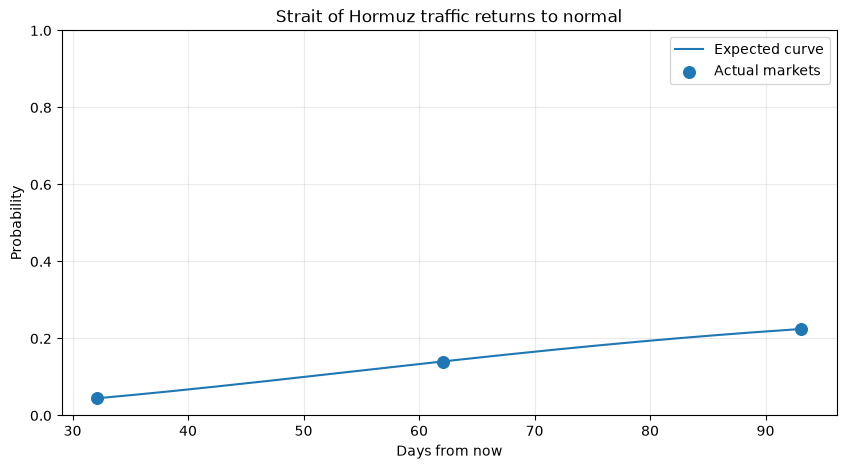


Russia x Ukraine ceasefire agreement
{'p_max': np.float64(0.8113737726643887), 'never_probability': np.float64(0.1886262273356113), 'tau_days': np.float64(262.58186099744387), 'shape': np.float64(1.2584033613445378), 'mse': np.float64(6.800318091770361e-05)}


,deadline,days_away,actual,expected,residual
0,2026-11-01 03:59:00+00:00,33.3,6.50%,5.81%,+0.69%
1,2026-12-01 04:59:00+00:00,63.3,11.50%,12.48%,-0.98%
2,2027-01-01 04:59:00+00:00,94.3,19.50%,19.55%,-0.05%
3,2027-02-01 04:59:00+00:00,125.3,27.50%,26.43%,+1.07%
4,2027-03-01 04:59:00+00:00,153.3,30.50%,32.32%,-1.82%
5,2027-04-01 03:59:00+00:00,184.3,38.50%,38.37%,+0.13%
6,2027-05-01 03:59:00+00:00,214.3,43.50%,43.73%,-0.23%
7,2027-06-01 03:59:00+00:00,245.3,49.50%,48.73%,+0.77%
8,2027-07-01 03:59:00+00:00,275.3,52.50%,53.06%,-0.56%
9,2027-08-01 03:59:00+00:00,306.3,57.50%,57.03%,+0.47%


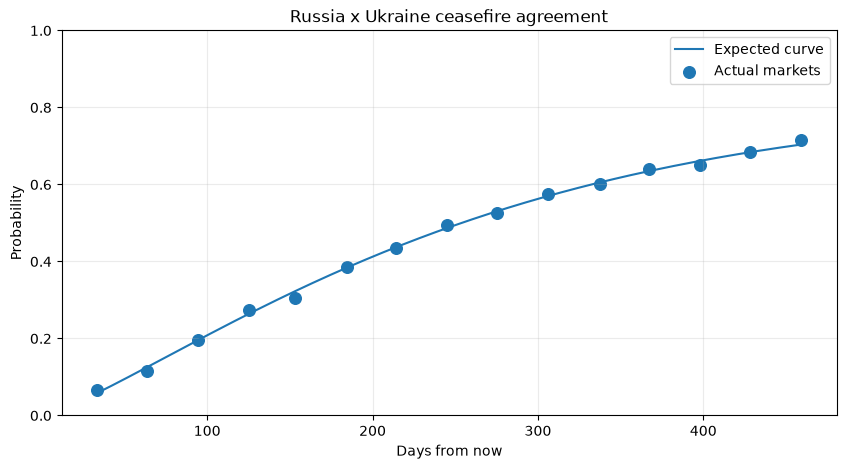


OpenAI announces another Millennium Prize solution
{'p_max': np.float64(0.8547764350692383), 'never_probability': np.float64(0.14522356493076172), 'tau_days': np.float64(244.02385935912656), 'shape': np.float64(0.8172268907563025), 'mse': np.float64(8.383077853307477e-08)}


,deadline,days_away,actual,expected,residual
0,2026-10-01 03:59:00+00:00,2.3,1.80%,1.85%,-0.05%
1,2027-01-01 04:59:00+00:00,94.3,31.50%,31.51%,-0.01%
2,2028-01-01 04:59:00+00:00,459.3,69.50%,69.50%,+0.00%


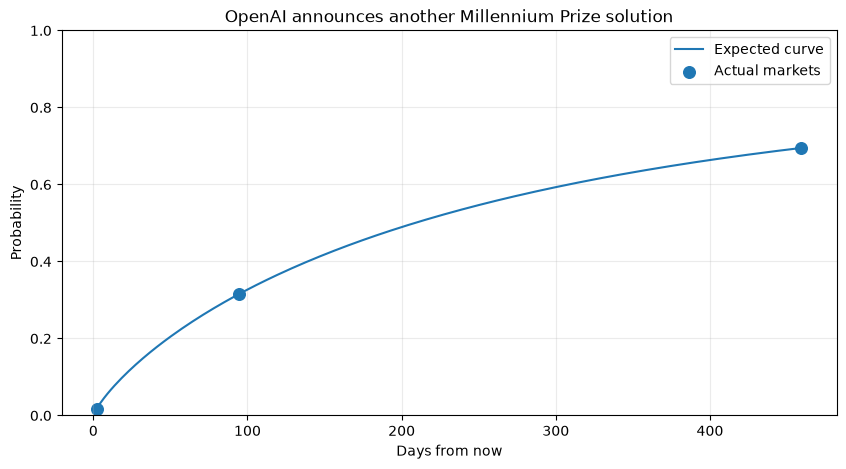


US-Iran ceasefire continues through
{'p_start': np.float64(1.0), 'tau_days': np.float64(75.96508786757549), 'shape': np.float64(0.7542016806722689), 'mse': np.float64(0.000459397068156626)}


,deadline,days_away,actual,expected,residual
0,2026-09-30 23:59:00+00:00,2.1,96.10%,93.53%,+2.57%
1,2026-10-31 23:59:00+00:00,33.1,57.50%,58.60%,-1.10%
2,2026-11-30 23:59:00+00:00,63.1,40.00%,41.92%,-1.92%
3,2026-12-31 23:59:00+00:00,94.1,33.50%,30.87%,+2.63%


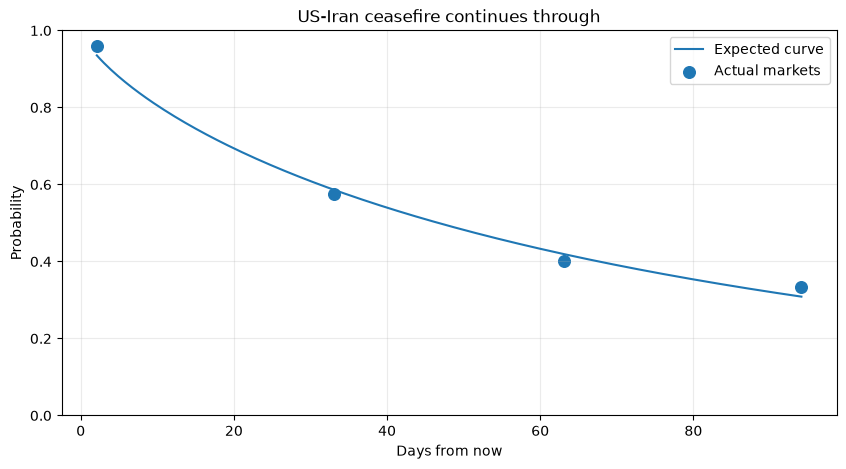


US announces end of Iranian blockade
{'p_max': np.float64(1.0), 'never_probability': np.float64(0.0), 'tau_days': np.float64(119.36273218323893), 'shape': np.float64(0.8172268907563025), 'mse': np.float64(0.0003968509311829589)}


,deadline,days_away,actual,expected,residual
0,2026-10-01 03:59:00+00:00,2.3,3.35%,3.85%,-0.50%
1,2026-10-16 03:59:00+00:00,17.3,18.50%,18.62%,-0.12%
2,2026-11-01 03:59:00+00:00,33.3,31.50%,29.67%,+1.83%
3,2026-12-01 04:59:00+00:00,63.3,41.00%,44.88%,-3.88%
4,2027-01-01 04:59:00+00:00,94.3,58.45%,56.17%,+2.28%
5,2027-04-01 03:59:00+00:00,184.3,76.00%,75.97%,+0.03%


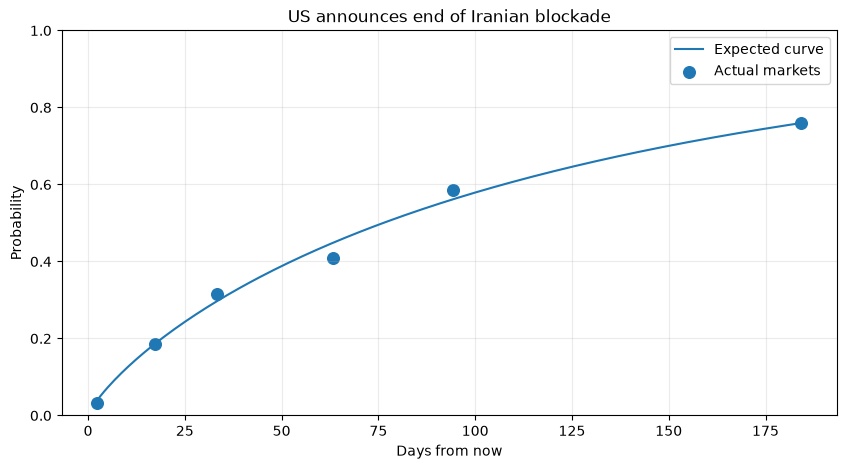

In [24]:
for family_key in price_data:

    try:
        result = expected_curve(family_key)

        comparison = result["comparison"]

        print("\n" + "=" * 80)
        print(EVENTS[family_key]["name"])
        print(result["parameters"])

        display(
            comparison.style.format({
                "days_away": "{:.1f}",
                "actual": "{:.2%}",
                "expected": "{:.2%}",
                "residual": "{:+.2%}",
            })
        )

        plt.figure(figsize=(10, 5))

        # Smooth expected curve
        plt.plot(
            result["curve_days"],
            result["curve_probability"],
            label="Expected curve",
        )

        # Actual Polymarket probabilities
        plt.scatter(
            comparison["days_away"],
            comparison["actual"],
            label="Actual markets",
            s=70,
        )

        plt.xlabel("Days from now")
        plt.ylabel("Probability")
        plt.title(EVENTS[family_key]["name"])
        plt.ylim(0, 1)
        plt.legend()
        plt.grid(alpha=0.25)
        plt.show()

    except Exception as e:
        print(f"{family_key}: {e}")